<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

<h1 style="color:RGB(0,114,200)">
ÉTUDE DE L'ALIMENTATION MONDIALE
</h1>

![logo_FAO](img/logo_FAO.png)

La <a href="https://www.fao.org" style="color:RGB(0,114,200)">Food and Agriculture Organization of the United Nations (FAO)</a> est un organe de l'O.N.U. dont l'objectif est d'atteindre la sécurité alimentaire dans le monde.

En tant que Data Analyst de la F.A.O., j'ai réalisé une étude de l'alimentation et de la sous-nutrition dans le monde entre 2013 et 2017 à partir des données fournies par la FAO.

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

#Importation de la librairie Numpy 
import numpy as np

#Importation de la librairie Pyplot
import matplotlib.pyplot as plt

#Importation de la librairie Seaborn
import seaborn as sns

#Importation de la librairie ticker
import matplotlib.ticker as ticker

#Importation de la librairie graph
import plotly.graph_objects as go

#Importation de la librairie subplots
from plotly.subplots import make_subplots

#Importation de la librairie spearmanr
from scipy.stats import spearmanr

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('DAN-P4-FAO/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('DAN-P4-FAO/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('DAN-P4-FAO/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('DAN-P4-FAO/sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le dataset population possède {} lignes".format(population.shape[0]))
print("Le dataset population possède {} colonnes".format(population.shape[1]))

Le dataset population possède 1416 lignes
Le dataset population possède 3 colonnes


In [4]:
#Consulter le nombre de colonnes
print("Colonnes du dataset population {}".format(list(population.columns)))
print("-----------------------------------------------------------------------")
#La nature des données dans chacune des colonnes
print("Type de la colonne du dataset population \n{}".format(population.dtypes))
print("-----------------------------------------------------------------------")
#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(population.columns):
    print("Nombre de valeurs de la colonne {} : {}".format(column, len(population.value_counts(column).reset_index())))
    print("-----------------------------------------------------------------------")

print("Information du dataset population")
display(population.info())
print("-----------------------------------------------------------------------")
print("Statistiques descriptive du dataset population")
display(population.describe(include="all"))

Colonnes du dataset population ['Zone', 'Année', 'Valeur']
-----------------------------------------------------------------------
Type de la colonne du dataset population 
Zone       object
Année       int64
Valeur    float64
dtype: object
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Zone : 236
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Année : 6
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Valeur : 1413
-----------------------------------------------------------------------
Information du dataset population
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64

None

-----------------------------------------------------------------------
Statistiques descriptive du dataset population


,Zone,Année,Valeur
count,1416,1416.000000,1.416000e+03
unique,236,NaN,NaN
top,Afghanistan,NaN,NaN
freq,6,NaN,NaN
mean,NaN,2015.500000,3.144793e+04
std,NaN,1.708428,1.300812e+05
min,NaN,2013.000000,7.930000e-01
25%,NaN,2014.000000,3.783410e+02
50%,NaN,2015.500000,5.126480e+03
75%,NaN,2017.000000,1.930666e+04


In [5]:
#Affichage les 5 premières lignes de la table
print("5 première lignes du dataset population")
population.head()

5 première lignes du dataset population


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000

#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur'] * 1000

population.head()


,Zone,Année,Valeur
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur': 'Population'}, inplace=True)


In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Le dataset <b>population</b> contient le nombre d'habitant de 236 pays sur les années 2013 à 2018
<br />
Ce dataset est composé de <b>1416 lignes</b> et <b>3 colonnes</b>
<br />
Toutes les lignes du dataset sont renseignées
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Le dataset dispo alimentaire possède {} lignes".format(dispo_alimentaire.shape[0]))
print("Le dataset dispo alimentaire possède {} colonnes".format(dispo_alimentaire.shape[1]))

Le dataset dispo alimentaire possède 15605 lignes
Le dataset dispo alimentaire possède 18 colonnes


In [10]:
#Consulter le nombre de colonnes
print("Colonnes du dataset dispo alimentaire \n{}".format(list(dispo_alimentaire.columns)))
print("-----------------------------------------------------------------------")
#La nature des données dans chacune des colonnes
print("Type de la colonne du dataset dispo alimentaire \n{}".format(dispo_alimentaire.dtypes))
print("-----------------------------------------------------------------------")
#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(dispo_alimentaire.columns):
    print("Nombre de valeurs de la colonne {} : {}".format(column, len(dispo_alimentaire.value_counts(column).reset_index())))
    print("-----------------------------------------------------------------------")

print("Information du dataset dispo alimentaire")
display(dispo_alimentaire.info())
print("-----------------------------------------------------------------------")
print("Statistiques descriptive du dataset dispo alimentaire")
display(dispo_alimentaire.describe(include="all"))


Colonnes du dataset dispo alimentaire 
['Zone', 'Produit', 'Origine', 'Aliments pour animaux', 'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']
-----------------------------------------------------------------------
Type de la colonne du dataset dispo alimentaire 
Zone                                                              object
Produit                                                           object
Origine                                                           object
Aliments pour animaux                                            float64
Autres Utilisations                                              flo

None

-----------------------------------------------------------------------
Statistiques descriptive du dataset dispo alimentaire


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
count,15605,15605,15605,2720.000000,5496.000000,14241.000000,14015.000000,11794.000000,11561.000000,15382.000000,12226.000000,14852.000000,14015.000000,4278.000000,9180.000000,2091.000000,2292.000000,6776.000000
unique,174,98,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Inde,Abats Comestible,vegetale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,97,174,11896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,479.501838,157.391376,34.789832,8.719368,1.283111,1.223608,640.293460,110.596925,87.264543,347.931359,106.053763,1090.379085,73.974653,961.905323,-15.407615
std,NaN,NaN,NaN,4240.119637,5076.785816,107.287655,24.618223,3.680399,3.598686,9067.267153,1053.318990,717.372714,4475.704458,1113.100416,12067.344094,528.069224,10381.795904,549.834540
min,NaN,NaN,NaN,0.000000,0.000000,-21.000000,-1.930000,-0.030000,-0.370000,-3430.000000,-41.000000,-201.000000,-246.000000,0.000000,0.000000,0.000000,-19.000000,-39863.000000
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.060000,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,4.000000,0.000000,4.000000,0.830000,0.080000,0.100000,7.000000,0.000000,2.000000,5.000000,4.000000,22.000000,2.000000,6.000000,0.000000
75%,NaN,NaN,NaN,74.000000,4.000000,21.000000,5.190000,0.630000,0.660000,76.750000,9.000000,18.000000,52.000000,26.000000,191.250000,17.000000,69.000000,0.000000


In [11]:
print("Valeurs de la colonne Produit")
display(list(dispo_alimentaire['Produit'].unique()))
display("------------------------------------------------------")
print("Valeurs de la colonne Origine")
display(list(dispo_alimentaire['Origine'].unique()))

Valeurs de la colonne Produit


['Abats Comestible',
 'Agrumes, Autres',
 'Aliments pour enfants',
 'Ananas',
 'Bananes',
 'Beurre, Ghee',
 'Bière',
 'Blé',
 'Boissons Alcooliques',
 'Café',
 'Coco (Incl Coprah)',
 'Crème',
 'Céréales, Autres',
 'Dattes',
 'Edulcorants Autres',
 'Feve de Cacao',
 'Fruits, Autres',
 'Graines de coton',
 'Graines de tournesol',
 'Graisses Animales Crue',
 'Huil Plantes Oleif Autr',
 'Huile Graines de Coton',
 "Huile d'Arachide",
 "Huile d'Olive",
 'Huile de Colza&Moutarde',
 'Huile de Palme',
 'Huile de Soja',
 'Huile de Sésame',
 'Huile de Tournesol',
 'Lait - Excl Beurre',
 'Légumes, Autres',
 'Légumineuses Autres',
 'Maïs',
 'Miel',
 'Millet',
 'Miscellanees',
 'Noix',
 'Oeufs',
 'Olives',
 'Oranges, Mandarines',
 'Orge',
 'Plantes Oleiferes, Autre',
 'Poissons Eau Douce',
 'Poivre',
 'Pommes',
 'Pommes de Terre',
 'Raisin',
 'Riz (Eq Blanchi)',
 'Sucre Eq Brut',
 'Sucre, betterave',
 'Sucre, canne',
 'Sésame',
 'Thé',
 'Tomates',
 "Viande d'Ovins/Caprins",
 'Viande de Bovins',
 'Vi

'------------------------------------------------------'

Valeurs de la colonne Origine


['animale', 'vegetale']

In [12]:
#Affichage les 5 premières lignes de la table
print("5 premières lignes du datset dispo alimentaire")
dispo_alimentaire.head()

5 premières lignes du datset dispo alimentaire


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [13]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [14]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire['Aliments pour animaux'] = dispo_alimentaire['Aliments pour animaux'] * 1000
dispo_alimentaire['Autres Utilisations'] = dispo_alimentaire['Autres Utilisations'] * 1000
dispo_alimentaire['Disponibilité intérieure'] = dispo_alimentaire['Disponibilité intérieure'] * 1000
dispo_alimentaire['Exportations - Quantité'] = dispo_alimentaire['Exportations - Quantité'] * 1000
dispo_alimentaire['Importations - Quantité'] = dispo_alimentaire['Importations - Quantité'] * 1000
dispo_alimentaire['Nourriture'] = dispo_alimentaire['Nourriture'] * 1000
dispo_alimentaire['Pertes'] = dispo_alimentaire['Pertes'] * 1000
dispo_alimentaire['Production'] = dispo_alimentaire['Production'] * 1000
dispo_alimentaire['Semences'] = dispo_alimentaire['Semences'] * 1000
dispo_alimentaire['Traitement'] = dispo_alimentaire['Traitement'] * 1000
dispo_alimentaire['Variation de stock'] = dispo_alimentaire['Variation de stock'] * 1000


In [15]:
#Affichage les 5 premières lignes de la table
print("5 premières lignes du dataset dispo alimentaire")
dispo_alimentaire.head()


5 premières lignes du dataset dispo alimentaire


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Le dataset <b>dispo alimentaire</b> contient les disponibilités  et les utilisations des matière première alimentaire de 174 pays et l'originie animale ou végétale de la denrée
<br />
Ce dataset est composé de <b>15605 lignes</b> et <b>18 colonnes</b>
<br />
Les valeurs de certaines disponibilité ne sont pas remplies et ont été remplacée par 0
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [16]:
#Afficher les dimensions du dataset
print("Le dataset aide alimentaire possède {} lignes".format(aide_alimentaire.shape[0]))
print("Le dataset aide alimentaire possède {} colonnes".format(aide_alimentaire.shape[1]))

Le dataset aide alimentaire possède 1475 lignes
Le dataset aide alimentaire possède 4 colonnes


In [17]:
#Consulter le nombre de colonnes
print("Colonnes du dataset aide alimentaire \n{}".format(list(aide_alimentaire.columns)))
print("-----------------------------------------------------------------------")
#La nature des données dans chacune des colonnes
print("Type de la colonne du dataset aide alimentaire \n{}".format(aide_alimentaire.dtypes))
print("-----------------------------------------------------------------------")
#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(aide_alimentaire.columns):
    print("Nombre de valeurs de la colonne {} : {}".format(column, len(aide_alimentaire.value_counts(column).reset_index())))
    print("-----------------------------------------------------------------------")

print("Information du dataset aide alimentaire")
display(aide_alimentaire.info())
print("-----------------------------------------------------------------------")
print("Statistiques descriptive du dataset aide alimentaire")
display(aide_alimentaire.describe(include="all"))

Colonnes du dataset aide alimentaire 
['Pays bénéficiaire', 'Année', 'Produit', 'Valeur']
-----------------------------------------------------------------------
Type de la colonne du dataset aide alimentaire 
Pays bénéficiaire    object
Année                 int64
Produit              object
Valeur                int64
dtype: object
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Pays bénéficiaire : 76
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Année : 4
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Produit : 16
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Valeur : 1086
-----------------------------------------------------------------------
Information du dataset aide alimentaire
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Da

None

-----------------------------------------------------------------------
Statistiques descriptive du dataset aide alimentaire


,Pays bénéficiaire,Année,Produit,Valeur
count,1475,1475.000000,1475,1475.000000
unique,76,NaN,16,NaN
top,Algérie,NaN,Non-céréales,NaN
freq,39,NaN,220,NaN
mean,NaN,2014.054237,NaN,7481.966780
std,NaN,0.946916,NaN,23339.531424
min,NaN,2013.000000,NaN,0.000000
25%,NaN,2013.000000,NaN,287.500000
50%,NaN,2014.000000,NaN,1178.000000
75%,NaN,2015.000000,NaN,4334.500000


In [18]:
print("Valeurs de la colonne produit")
list(aide_alimentaire['Produit'].unique())

Valeurs de la colonne produit


['Autres non-céréales',
 'Blé et Farin',
 'Céréales',
 'Fruits secs, total',
 'Huiles végétales',
 'Légumineuses Sèches,Tot.',
 'Non-céréales',
 'Riz, total',
 'Sucre, total',
 'Céréales Secondaires',
 'Lait, total',
 'Mélanges et préparations',
 'Poiss&produi',
 'BulgurFarEnt',
 'Viande Total',
 'Graisses Com']

In [19]:
#Affichage les 5 premières lignes de la table
print("5 premières lignes du dataset aide alimentaire")
aide_alimentaire.head()

5 premières lignes du dataset aide alimentaire


,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [20]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [21]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = aide_alimentaire['Valeur'] * 1000
aide_alimentaire.rename(columns={'Valeur': 'Aide_alimentaire'}, inplace=True)

In [22]:
#Affichage les 5 premières lignes de la table
print("5 premières lignes du dataset aide alimentaire")
aide_alimentaire.head()

5 premières lignes du dataset aide alimentaire


,Zone,Année,Produit,Aide_alimentaire
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Le dataset <b>aide alimentaire</b> la quantité d'aide alimentaire en kg accordée dans 76 pays dans les années 2013 à 2016
<br />
Ce dataset est composé de <b>1475 lignes</b> et <b>4 colonnes</b>
<br />
Toutes les colonnes du dataset sont remplies
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [23]:
#Afficher les dimensions du dataset
print("Le dataset sous nutrition possède {} lignes".format(sous_nutrition.shape[0]))
print("Le dataset sous nutrition possède {} colonnes".format(sous_nutrition.shape[1]))


Le dataset sous nutrition possède 1218 lignes
Le dataset sous nutrition possède 3 colonnes


In [24]:
#Consulter le nombre de colonnes
print("Colonnes du dataset sous nutrition \n{}".format(list(sous_nutrition.columns)))
print("-----------------------------------------------------------------------")
#La nature des données dans chacune des colonnes
print("Type de la colonne du dataset sous nutrition \n{}".format(sous_nutrition.dtypes))
print("-----------------------------------------------------------------------")
#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(sous_nutrition.columns):
    print("Nombre de valeurs de la colonne {} : {}".format(column, len(sous_nutrition.value_counts(column).reset_index())))
    print("-----------------------------------------------------------------------")

print("Information du dataset sous nutrition")
display(sous_nutrition.info())
print("-----------------------------------------------------------------------")
print("Statistiques descriptive du dataset sous nutrition")
display(sous_nutrition.describe(include="all"))


Colonnes du dataset sous nutrition 
['Zone', 'Année', 'Valeur']
-----------------------------------------------------------------------
Type de la colonne du dataset sous nutrition 
Zone      object
Année     object
Valeur    object
dtype: object
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Zone : 203
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Année : 6
-----------------------------------------------------------------------
Nombre de valeurs de la colonne Valeur : 139
-----------------------------------------------------------------------
Information du dataset sous nutrition
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: obj

None

-----------------------------------------------------------------------
Statistiques descriptive du dataset sous nutrition


,Zone,Année,Valeur
count,1218,1218,624
unique,203,6,139
top,Afghanistan,2012-2014,<0.1
freq,6,203,120


In [25]:
print("Valeurs de la colonne Année")
list(sous_nutrition['Année'].unique())

Valeurs de la colonne Année


['2012-2014', '2013-2015', '2014-2016', '2015-2017', '2016-2018', '2017-2019']

In [26]:
#Afficher les 5 premières lignes de la table
print("5 premières lignes du dataset sous nutrition")
sous_nutrition.head()


5 premières lignes du dataset sous nutrition


,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [27]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'],errors='coerce')

#Récupération des données de sous-nutrition sans remplissage des valeurs manquantes
sous_nutrition_orig = sous_nutrition

In [28]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition = sous_nutrition.fillna(0)

In [29]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={'Valeur': 'sous_nutrition'}, inplace=True)

In [30]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] = sous_nutrition['sous_nutrition'] * 1000000

In [31]:
#Afficher les 5 premières lignes de la table
print("5 premières lignes du dataset sous nutrition")
sous_nutrition.head()


5 premières lignes du dataset sous nutrition


,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Le dataset <b>sous nutrition</b> contient le nombre d'habitants en état de sous-nutrition de 203 pays de 2013 à 2018
Ce dataset est composé de <b>1218 lignes</b> et <b>3 colonnes</b>
<br />
Les valeurs de certaines disponibilité ne sont pas remplies
</p>
</div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Analyse des données</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [32]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
population_2017 = population[population['Année'] == 2017]
sous_nutrition_2017 = sous_nutrition[sous_nutrition['Année'] == '2016-2018']
population_sous_nutrition_2017 = pd.merge(left=sous_nutrition_2017, right=population_2017, on='Zone', how='inner')
population_sous_nutrition_2017.rename(columns={'Année_x': 'Année_population', 'Année_y': 'Année_sous_nutrition'}, inplace=True)


In [33]:
#Affichage du dataset
population_sous_nutrition_2017.head()

,Zone,Année_population,sous_nutrition,Année_sous_nutrition,Population
0,Afghanistan,2016-2018,10500000.0,2017,36296113.0
1,Afrique du Sud,2016-2018,3100000.0,2017,57009756.0
2,Albanie,2016-2018,100000.0,2017,2884169.0
3,Algérie,2016-2018,1300000.0,2017,41389189.0
4,Allemagne,2016-2018,0.0,2017,82658409.0


In [34]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
nb_pers_sous_nutrition_2017 = population_sous_nutrition_2017["sous_nutrition"].sum()
print("Nombre de personnes en état de sous nutrition en 2017 : {:,}".format(int(nb_pers_sous_nutrition_2017)))

Nombre de personnes en état de sous nutrition en 2017 : 535,700,000


In [35]:
#Population mondiale
population_mondiale_2017 = population_2017['Population'].sum()
print("La population mondiale en 2017 : {:,}".format(int(population_mondiale_2017)))

La population mondiale en 2017 : 7,548,134,111


In [36]:
#Proportion des personnes en état de sous nutrition
proportion_sous_nutrition_2017 = nb_pers_sous_nutrition_2017 / population_mondiale_2017
print("Proportion des personnes en état de sous-nutrition en 2017 : {:.2%}".format(proportion_sous_nutrition_2017))

Proportion des personnes en état de sous-nutrition en 2017 : 7.10%


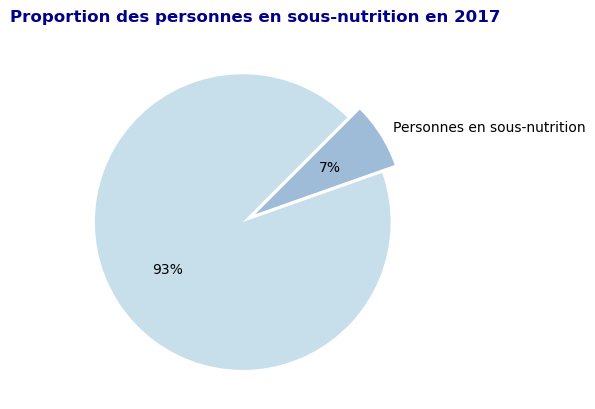

In [37]:
#Affichage de la proportion de la sous-nutrition en 2017  sous la forme d'un camembert
data_sous_nutrition_2017 = {'label': ['', 'Personnes en sous-nutrition'], 'valeur': [population_mondiale_2017 - nb_pers_sous_nutrition_2017, nb_pers_sous_nutrition_2017]}
dataframe_sous_nutrition_2017 = pd.DataFrame(data=data_sous_nutrition_2017)

plt.pie(
    x=dataframe_sous_nutrition_2017["valeur"], 
    startangle = 45,
    labels=dataframe_sous_nutrition_2017["label"],
    colors=sns.color_palette("ch:s=.25,rot=-.25"),
    autopct='%.0f%%', explode=(0.1, 0.0)
)

plt.title("Proportion des personnes en sous-nutrition en 2017", weight="bold", color='darkblue')

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
En 2017 le taux de sous-nutrition dans le monde était de <b>7%</b>
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [38]:
#Combien mange en moyenne un être humain ? Source => 
#https://www.anses.fr/fr/content/inca-3-evolution-des-habitudes-et-modes-de-consommation-de-nouveaux-enjeux-en-matiere-de#:~:text=Les%20Fran%C3%A7ais%20consomment%20en%20moyenne,la%20volaille%20et%20les%20soupes.
#2200 kcal pour un adulte par jour
nourriture_kcal_par_jour_par_personne = 2200

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
D'après <a href='https://www.anses.fr/fr/content/inca-3-evolution-des-habitudes-et-modes-de-consommation-de-nouveaux-enjeux-en-matiere-de#:~:text=Les%20Fran%C3%A7ais%20consomment%20en%20moyenne,la%20volaille%20et%20les%20soupes'
style='color:RGB(0,150,250);font-weight:bold;'>
l'Agence Nationale de Sécurité Sanitaire,
</a> un être humain adulte consomme en une journée <b>2200 calories</b>.
</p>
</div>

In [39]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dispo_alimentaire_poulation_2017 = pd.merge(left=population_2017, right=dispo_alimentaire, on='Zone', how="inner")

In [40]:
#Affichage du nouveau dataframe
dispo_alimentaire_poulation_2017.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


In [41]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement

#Dataframe contenant les colonnes Zone, Disponibilité alimentaire (Kcal/personne/jour), Année et Population 
dispo_alimentaire_par_kcal_2017 = dispo_alimentaire_poulation_2017[['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Population']]

#Calcul de la disponibilité des aliment en kcal par pays et par Année
dispo_alimentaire_par_kcal_jour_2017_serie =  dispo_alimentaire_par_kcal_2017['Population'] * dispo_alimentaire_par_kcal_2017['Disponibilité alimentaire (Kcal/personne/jour)']
dispo_kcal_jour_2017 = dispo_alimentaire_par_kcal_jour_2017_serie.sum()

print('{:,.0f} calories sont disponibles par jour dans le monde.'.format(dispo_kcal_jour_2017))

20,918,984,627,331 calories sont disponibles par jour dans le monde.


In [42]:
#Calcul du nombre d'humains pouvant être nourris

humain_pouvant_etre_nourris_2017 = dispo_kcal_jour_2017 / nourriture_kcal_par_jour_par_personne
print("Le nombre d'humains pouvant être nourris en 2017 {:,.0f}".format(humain_pouvant_etre_nourris_2017),"alors que la population mondiale en 2017 est de","{:,.0f}".format(population_mondiale_2017))

print("La proportion de personne pouvant être nourris en 2017 est de {:.2%}".format(humain_pouvant_etre_nourris_2017 / population_mondiale_2017))


Le nombre d'humains pouvant être nourris en 2017 9,508,629,376 alors que la population mondiale en 2017 est de 7,548,134,111
La proportion de personne pouvant être nourris en 2017 est de 125.97%


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
En 2017 le nombre d'humain pouvant être nourris <b>9,5 millards</b> alors que la population mondiale est de <b>7,5 milliards</b> d'habitants
<br>
Ce qui représente <b>126%</b> de la population
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [43]:
#Transfert des données avec les végétaux dans un nouveau dataframe
dispo_alimentaire_poulation_2017_vegetaux = dispo_alimentaire_poulation_2017[dispo_alimentaire_poulation_2017['Origine'] == 'vegetale']
dispo_alimentaire_poulation_2017_vegetaux.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0
6,Afghanistan,2017,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000.0,0.0,3000.0,3000.0,0.0,0.0,0.0,0.0,0.0


In [44]:
#Calcul du nombre de kcal disponible pour les végétaux

#Dataframe contenant les colonnes Zone, Disponibilité alimentaire (Kcal/personne/jour), Année et Population 
dispo_alimentaire_vegetaux_par_kcal_2017 = dispo_alimentaire_poulation_2017_vegetaux[['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Population']]

#Calcul de la disponibilité des aliment en kcal par pays et par Année
dispo_kcal_jour_vegetaux_serie =  dispo_alimentaire_vegetaux_par_kcal_2017['Population'] *  dispo_alimentaire_vegetaux_par_kcal_2017['Disponibilité alimentaire (Kcal/personne/jour)']

dispo_kcal_jour_vegetaux_2017 = dispo_kcal_jour_vegetaux_serie.sum()

print('{:,.0f} calories de végétaux sont disponibles par jour dans le monde.'.format(dispo_kcal_jour_vegetaux_2017))

17,260,764,211,501 calories de végétaux sont disponibles par jour dans le monde.


In [45]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
humain_pouvant_etre_nourris_vegetaux_2017 = dispo_kcal_jour_vegetaux_2017 / nourriture_kcal_par_jour_par_personne
print("Le nombre d'humains pouvant être nourris avec des végétaux en 2017 est de {:,.0f}".format(humain_pouvant_etre_nourris_vegetaux_2017),"alors que la population mondiale en 2017 est de","{:,.0f}".format(population_mondiale_2017))

print("La proportion de personne pouvant être nourris de végétaux en 2017 est de {:.2%}".format(humain_pouvant_etre_nourris_vegetaux_2017 / population_mondiale_2017))


Le nombre d'humains pouvant être nourris avec des végétaux en 2017 est de 7,845,801,914 alors que la population mondiale en 2017 est de 7,548,134,111
La proportion de personne pouvant être nourris de végétaux en 2017 est de 103.94%


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
En 2017 le nombre d'humain pouvant être nourris <b>7,8 millards</b> alors que la population mondiale est de <b>7,5 milliards</b> d'habitants
</br>
Ce qui représente <b>104%</b> de la population
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [46]:
#Calcul de la disponibilité totale
disponibilite_interieur_totale = dispo_alimentaire['Disponibilité intérieure'].sum()
print("La disponibilite intérieure mondiale totale est de {:,.0f} kg".format(disponibilite_interieur_totale))

La disponibilite intérieure mondiale totale est de 9,848,994,000 kg


In [47]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 

columns = ['Aliments pour animaux', 'Nourriture', 'Pertes','Semences','Traitement','Autres Utilisations']

#Dictionnaire contenant en clé le type d'utilisation de la nourriture et en valeur la quantité utilisée
dico_disponibite_interieure = {}
print("Répartition de la disponibilité intérieure :")
for column in columns:
   total = dispo_alimentaire[column].sum()
   dico_disponibite_interieure[column] = total
   print("\t",column,": {:,.0f}".format(total), "kg")

Répartition de la disponibilité intérieure :
	 Aliments pour animaux : 1,304,245,000 kg
	 Nourriture : 4,876,258,000 kg
	 Pertes : 453,698,000 kg
	 Semences : 154,681,000 kg
	 Traitement : 2,204,687,000 kg
	 Autres Utilisations : 865,023,000 kg


Répartition de la disponibilité intérieure


,variable,value
0,Aliments pour animaux,1.304245e+09
1,Nourriture,4.876258e+09
2,Pertes,4.536980e+08
3,Semences,1.546810e+08
4,Traitement,2.204687e+09
5,Autres Utilisations,8.650230e+08


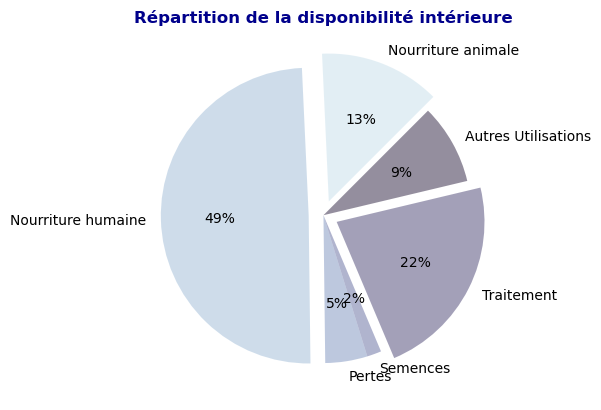

In [48]:
#Graphique représentant la repartition de la disponibilité intérieure

df_disponibite_interieure = pd.DataFrame(data=dico_disponibite_interieure, index=[0])
df_disponibite_interieure = df_disponibite_interieure.melt()
print("Répartition de la disponibilité intérieure")
display(df_disponibite_interieure)

plt.pie(
    x=df_disponibite_interieure["value"], 
    startangle = 45,
    labels=['Nourriture animale', 'Nourriture humaine', 'Pertes','Semences','Traitement','Autres Utilisations'],
    colors=sns.color_palette("ch:s=.25,rot=-.25"),
    autopct='%.0f%%', explode=(0.1, 0.1, 0, 0, 0.1, 0),
    wedgeprops={'alpha':0.5}
)

plt.title("Répartition de la disponibilité intérieure", weight="bold", color='darkblue')

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les produits alimentaires sont principalement utilisées pour <b>la nutrition humaine</b>, <b>le traitement</b> et <b>l'alimentation animale</b>
</p>
</div>

In [49]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes production, imporation, exportation et variation de stock

columns = ['Production', 'Importations - Quantité', 'Exportations - Quantité','Variation de stock']

#Dictionnaire contenant en clé le type d'utilisation de la nourriture et en valeur la quantité utilisée
dico_utilisation_denrees_alimentaire = {}
print("Répartition de l'utilisaton des denrées alimentaire :")
for column in columns:
   total = dispo_alimentaire[column].sum()
   dico_utilisation_denrees_alimentaire[column] = abs(total)
   print("\t",column,": {:,.0f}".format(total), "kg")

Répartition de l'utilisaton des denrées alimentaire :
	 Production : 10,009,680,000 kg
	 Importations - Quantité : 1,296,053,000 kg
	 Exportations - Quantité : 1,352,158,000 kg
	 Variation de stock : -104,402,000 kg


Répartition de l'utilisation des denrées alimentaire


,variable,value
0,Production,1.000968e+10
1,Importations - Quantité,1.296053e+09
2,Exportations - Quantité,1.352158e+09
3,Variation de stock,1.044020e+08


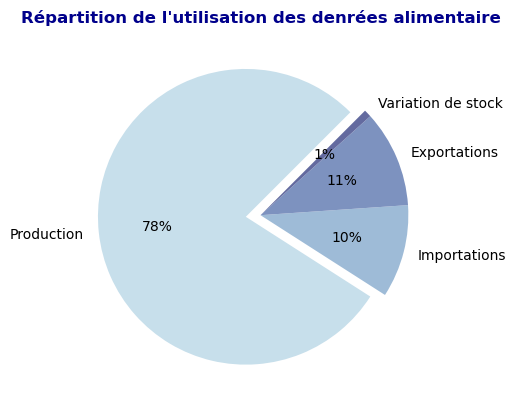

In [50]:
#Graphique représentant la repartition de la disponibilité intérieure

df_reparition_denrees = pd.DataFrame(data=dico_utilisation_denrees_alimentaire, index=[0])
df_reparition_denrees = df_reparition_denrees.melt()
print("Répartition de l'utilisation des denrées alimentaire")
display(df_reparition_denrees)

plt.pie(
    x=df_reparition_denrees["value"], 
    startangle = 45,
    labels=['Production', 'Importations', 'Exportations','Variation de stock'],
    colors=sns.color_palette("ch:s=.25,rot=-.25"),
    autopct='%.0f%%', explode=(0.1, 0, 0, 0)
)

plt.title("Répartition de l'utilisation des denrées alimentaire", weight="bold", color='darkblue')

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les produits alimentaire sont principalement utilisées pour <b>la production</b>
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [51]:
#Création d'une liste avec toutes les variables
dispo_alimentaire_column = list(dispo_alimentaire.columns)
dispo_alimentaire_column


['Zone',
 'Produit',
 'Origine',
 'Aliments pour animaux',
 'Autres Utilisations',
 'Disponibilité alimentaire (Kcal/personne/jour)',
 'Disponibilité alimentaire en quantité (kg/personne/an)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
 'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité intérieure',
 'Exportations - Quantité',
 'Importations - Quantité',
 'Nourriture',
 'Pertes',
 'Production',
 'Semences',
 'Traitement',
 'Variation de stock']

In [52]:
#Liste de tous les produits alimentaire
liste_produit_alimentaire = list(dispo_alimentaire['Produit'].unique())
liste_produit_alimentaire

['Abats Comestible',
 'Agrumes, Autres',
 'Aliments pour enfants',
 'Ananas',
 'Bananes',
 'Beurre, Ghee',
 'Bière',
 'Blé',
 'Boissons Alcooliques',
 'Café',
 'Coco (Incl Coprah)',
 'Crème',
 'Céréales, Autres',
 'Dattes',
 'Edulcorants Autres',
 'Feve de Cacao',
 'Fruits, Autres',
 'Graines de coton',
 'Graines de tournesol',
 'Graisses Animales Crue',
 'Huil Plantes Oleif Autr',
 'Huile Graines de Coton',
 "Huile d'Arachide",
 "Huile d'Olive",
 'Huile de Colza&Moutarde',
 'Huile de Palme',
 'Huile de Soja',
 'Huile de Sésame',
 'Huile de Tournesol',
 'Lait - Excl Beurre',
 'Légumes, Autres',
 'Légumineuses Autres',
 'Maïs',
 'Miel',
 'Millet',
 'Miscellanees',
 'Noix',
 'Oeufs',
 'Olives',
 'Oranges, Mandarines',
 'Orge',
 'Plantes Oleiferes, Autre',
 'Poissons Eau Douce',
 'Poivre',
 'Pommes',
 'Pommes de Terre',
 'Raisin',
 'Riz (Eq Blanchi)',
 'Sucre Eq Brut',
 'Sucre, betterave',
 'Sucre, canne',
 'Sésame',
 'Thé',
 'Tomates',
 "Viande d'Ovins/Caprins",
 'Viande de Bovins',
 'Vi

In [53]:
#Liste des céréales
liste_nom_cereales = ['Blé', 'Riz (Eq Blanchi)', 'Orge', 'Maïs', 'Seigle', 'Avoine', 'Millet', 'Sorgho', 'Céréales, Autres']

In [54]:
#Création d'un dataframe avec les informations uniquement pour ces céréales

dispo_alimentaire_cereales = dispo_alimentaire.loc[dispo_alimentaire['Produit'].isin(liste_nom_cereales),:]
dispo_alimentaire_cereales.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5992000.0,0.0,1173000.0,4895000.0,775000.0,5169000.0,322000.0,0.0,-350000.0
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,Afghanistan,Maïs,vegetale,200000.0,0.0,21.0,2.50,0.30,0.56,313000.0,0.0,1000.0,76000.0,31000.0,312000.0,5000.0,0.0,0.0
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,13000.0,0.0,0.0,12000.0,1000.0,13000.0,0.0,0.0,0.0
40,Afghanistan,Orge,vegetale,360000.0,0.0,26.0,2.92,0.24,0.79,524000.0,0.0,10000.0,89000.0,52000.0,514000.0,22000.0,0.0,0.0


In [55]:
#Affichage de la proportion d'alimentation animale
proportion_cereales_alimentation_animale_nourriture = dispo_alimentaire_cereales[['Nourriture','Aliments pour animaux']].sum()
cereales_pour_humains = proportion_cereales_alimentation_animale_nourriture['Nourriture']
cereales_pour_animaux = proportion_cereales_alimentation_animale_nourriture['Aliments pour animaux']

print("{:,.0f} kg de céréales sont utilisées pour la nutrition humaine".format(cereales_pour_humains))
print("{:,.0f} kg de céréales sont utilisées pour la nutrition animale".format(cereales_pour_animaux))


1,029,010,000 kg de céréales sont utilisées pour la nutrition humaine
873,535,000 kg de céréales sont utilisées pour la nutrition animale


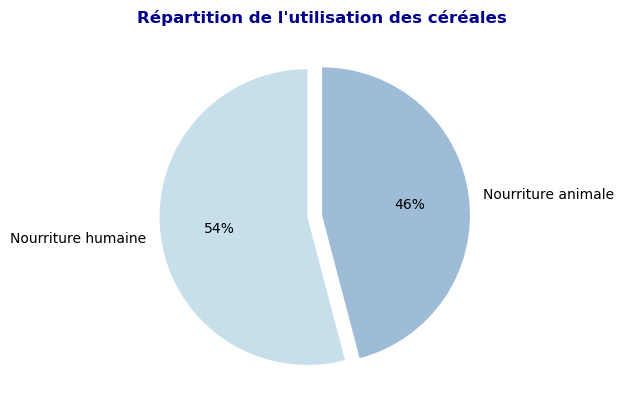

In [56]:
#Affichage de la proportion d'alimentation animale
proportion_cereales_alimentation_animale_nourriture.plot.pie(
    startangle = 90,
    labels=['Nourriture humaine', 'Nourriture animale'],
    colors=sns.color_palette("ch:s=.25,rot=-.25"),
    autopct='%.0f%%', 
    explode=(0.1, 0)
)

plt.title("Répartition de l'utilisation des céréales",weight="bold", color='darkblue')
plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
La céréales sont majoritairement utilisés pour la nutrition humaine
</p>
</div>

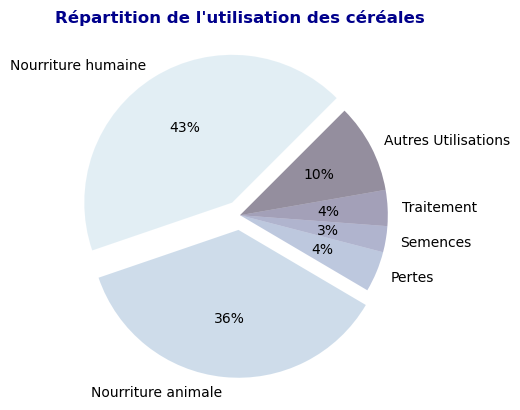

In [57]:
#Camembert représentant l'utilisation des céréales
proportion_dispo_alimentaire_cereales = dispo_alimentaire_cereales[['Nourriture','Aliments pour animaux','Pertes','Semences','Traitement','Autres Utilisations']].sum()
proportion_dispo_alimentaire_cereales.plot.pie(
    startangle = 45,
    labels=['Nourriture humaine', 'Nourriture animale', 'Pertes','Semences','Traitement','Autres Utilisations'],
    colors=sns.color_palette("ch:s=.25,rot=-.25"),
    autopct='%.0f%%', 
    explode=(0.1, 0.1, 0, 0 ,0, 0),
    wedgeprops={'alpha':0.5}
)

plt.title("Répartition de l'utilisation des céréales",weight="bold", color='darkblue')
plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
La céréales sont majoritairement utilisés pour <b>la nutrition des humains et des animaux</b>
</p>
</div>

In [58]:
#Calcul de la proption des céréales utilisée par les humains et les animaux par céréales
dispo_alimentaire_cereales_groupby_cereales = dispo_alimentaire_cereales.groupby("Produit")[['Nourriture','Aliments pour animaux','Pertes','Semences','Traitement','Autres Utilisations']].sum().reset_index()

#Conversion des quantité des kilos vers les tonnes pour que le graphique soit plus lisible
dispo_alimentaire_cereales_groupby_cereales["Nourriture_tonne"] = dispo_alimentaire_cereales_groupby_cereales["Nourriture"] / 1000
dispo_alimentaire_cereales_groupby_cereales["Aliments_pour_animaux_tonne"] = dispo_alimentaire_cereales_groupby_cereales["Aliments pour animaux"] / 1000
dispo_alimentaire_cereales_groupby_cereales["Pertes_tonne"] = dispo_alimentaire_cereales_groupby_cereales["Pertes"] / 1000
dispo_alimentaire_cereales_groupby_cereales["Semences_tonne"] = dispo_alimentaire_cereales_groupby_cereales["Semences"] / 1000
dispo_alimentaire_cereales_groupby_cereales["Traitement_tonne"] = dispo_alimentaire_cereales_groupby_cereales["Traitement"] / 1000
dispo_alimentaire_cereales_groupby_cereales["Autres_utilisations_tonne"] = dispo_alimentaire_cereales_groupby_cereales["Autres Utilisations"] / 1000

dispo_alimentaire_cereales_groupby_cereales

,Produit,Nourriture,Aliments pour animaux,Pertes,Semences,Traitement,Autres Utilisations,Nourriture_tonne,Aliments_pour_animaux_tonne,Pertes_tonne,Semences_tonne,Traitement_tonne,Autres_utilisations_tonne
0,Avoine,3903000.0,16251000.0,514000.0,2485000.0,36000.0,206000.0,3903.0,16251.0,514.0,2485.0,36.0,206.0
1,Blé,457824000.0,129668000.0,27530000.0,34283000.0,7877000.0,22424000.0,457824.0,129668.0,27530.0,34283.0,7877.0,22424.0
2,"Céréales, Autres",5324000.0,19035000.0,785000.0,1203000.0,160000.0,1388000.0,5324.0,19035.0,785.0,1203.0,160.0,1388.0
3,Maïs,125184000.0,546116000.0,40701000.0,6837000.0,47648000.0,189386000.0,125184.0,546116.0,40701.0,6837.0,47648.0,189386.0
4,Millet,23040000.0,3306000.0,2276000.0,682000.0,403000.0,196000.0,23040.0,3306.0,2276.0,682.0,403.0,196.0
5,Orge,6794000.0,92658000.0,4628000.0,8804000.0,26910000.0,654000.0,6794.0,92658.0,4628.0,8804.0,26910.0,654.0
6,Riz (Eq Blanchi),377286000.0,33594000.0,27378000.0,12194000.0,6740000.0,18464000.0,377286.0,33594.0,27378.0,12194.0,6740.0,18464.0
7,Seigle,5502000.0,8099000.0,562000.0,1262000.0,1120000.0,20000.0,5502.0,8099.0,562.0,1262.0,1120.0,20.0
8,Sorgho,24153000.0,24808000.0,2746000.0,788000.0,3695000.0,2049000.0,24153.0,24808.0,2746.0,788.0,3695.0,2049.0


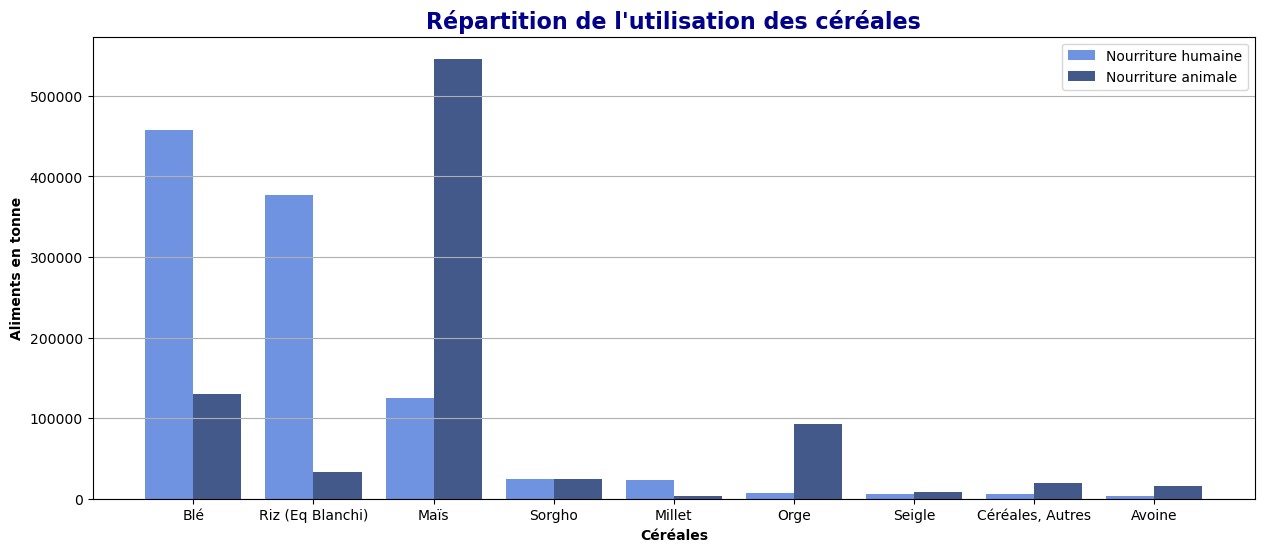

In [59]:
#Graphique en barre représentant l'utilisation de chaque céréales pour la nourriture animale et humaine

#Tri de la disponibilité des céréales par nourriture pour les humains
dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture = dispo_alimentaire_cereales_groupby_cereales.sort_values(by='Nourriture_tonne', ascending=False)

#Liste des nom des céréales
liste_nom_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Produit'])

#Liste de la quantité des céréales utilisée pour la nourriture humaine
liste_nourriture_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Nourriture_tonne'])

#Liste de la quantité des céréales utilisée pour la nourriture animale
liste_aliments_animaux_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Aliments_pour_animaux_tonne'])

#La variable largeur_barre représente la largeur des barres et la variable array_int_cereales contient un array commencant par 0 et contentant le nombre de céréales
largeur_barre, array_int_cereales = 0.4, np.arange(len(liste_nom_cereales))

#Graphique
plt.figure(figsize=(15, 6))
plt.bar(array_int_cereales - largeur_barre/2, liste_nourriture_cereales, largeur_barre, label='Nourriture humaine', color='#6F93E0')
plt.bar(array_int_cereales + largeur_barre/2, liste_aliments_animaux_cereales, largeur_barre, label='Nourriture animale', color='#435989')

#grille sur l'axe des ordonnées
plt.grid(axis='y')

#Libellés du graphique
plt.xticks(array_int_cereales, liste_nom_cereales)
plt.xlabel('Céréales', weight='bold')
plt.ylabel('Aliments en tonne', weight='bold')
plt.title("Répartition de l'utilisation des céréales", color='darkblue', fontsize=16, weight='bold')

plt.legend(loc='upper right')

plt.show()


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
<b>Le blé et le riz</b> sont les céréales les plus consommés par les humains
<br />
<b>Le mais</b> est la céréale la plus consommée par les animaux
</p>
</div>

In [60]:
#Graphique en barre représentant la disponibilité interne de chaque céréales

#Tri de la disponibilité des céréales par nourriture pour les humains
dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture = dispo_alimentaire_cereales_groupby_cereales.sort_values(by='Nourriture_tonne', ascending=False)

#Liste des nom des céréales
liste_nom_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Produit'])

#Liste de la quantité des céréales utilisée pour la nourriture humaine
liste_nourriture_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Nourriture_tonne'])

#Liste de la quantité des céréales utilisée pour la nourriture animale
liste_aliments_animaux_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Aliments_pour_animaux_tonne'])

#Liste de la quantité des céréales perdus
liste_pertes_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Pertes_tonne'])

#Liste de la quantité des céréales utilisée pour la semence
liste_semences_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Semences_tonne'])

#Liste de la quantité des céréales utilisée pour le traitement
liste_traitement_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Traitement_tonne'])

#Liste de la quantité des céréales utilisée pour d'autres utilisation
liste_autre_utilisation_cereales = list(dispo_alimentaire_cereales_groupby_cereales_order_by_nourriture['Autres_utilisations_tonne'])

#Graphique
font_title = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':16
}

font_label = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':12
}

fig = go.Figure(
    data=[
        go.Bar(name='Nourriture', x=liste_nom_cereales, y=liste_nourriture_cereales, marker_color='#2B1F3E'),
        go.Bar(name='Aliments pour animaux', x=liste_nom_cereales, y=liste_aliments_animaux_cereales, marker_color='#494373'),
        go.Bar(name='Pertes', x=liste_nom_cereales, y=liste_pertes_cereales, marker_color='#636A9F'),
        go.Bar(name='Semences', x=liste_nom_cereales, y=liste_semences_cereales, marker_color='#7D92BF'),
        go.Bar(name='Traitement', x=liste_nom_cereales, y=liste_traitement_cereales, marker_color='#9EBBD7'),
        go.Bar(name='Autres utilisations', x=liste_nom_cereales, y=liste_autre_utilisation_cereales, marker_color='#C7DFEB')
    ],
    layout = go.Layout(
        title = go.layout.Title(text = "Répartition de la disponibilité interne des céréales", font=font_title, x = 0.4),
        xaxis = go.layout.XAxis(title = 'Céréales', color='black'),
        yaxis = go.layout.YAxis(title = 'Aliments en tonne', color='black')
    )
)

fig.update_layout(
    barmode='group',
    height=800,
    font=font_label,
    legend=dict(x=0.87, y=0.99)
)
fig.show()


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
En interne les céréales sont principalement utilisées pour la nutrition humaine et végétale.
<br />
Le blé et le riz sont les céréales les plus consommés par les humains
<br />
Le maïs est la céréale la plus consommée par les animaux
<br />
Pour diminuer la sous-nutrition dans la monde il faudrait
 <br />
<b><i>Diminuer la part de maïs de la nourriture animale afin d'augmenter celle de la nourriture humaine</i></b>
<br />
<b><i>Si c'est possible produire plus de sorgho, millet, orge, seigle et avoine et d'utilisation cette production pour la nourriture humaine</i></b>
</p>
</div>

In [61]:
#Calcul de l'utilisation des céréales
utilisation_cereales_groupby_cereales = dispo_alimentaire_cereales.groupby("Produit")[['Exportations - Quantité','Importations - Quantité','Production','Variation de stock']].sum().reset_index()

#Conversion des quantité des kilos vers les tonnes pour que le graphique soit plus lisible
utilisation_cereales_groupby_cereales["Exportations_tonne"] = utilisation_cereales_groupby_cereales["Exportations - Quantité"] / 1000
utilisation_cereales_groupby_cereales["Importations_tonne"] = utilisation_cereales_groupby_cereales["Importations - Quantité"] / 1000
utilisation_cereales_groupby_cereales["Production_tonne"] = utilisation_cereales_groupby_cereales["Production"] / 1000
utilisation_cereales_groupby_cereales["Variation_stock_tonne"] = utilisation_cereales_groupby_cereales["Variation de stock"] / 1000

utilisation_cereales_groupby_cereales

,Produit,Exportations - Quantité,Importations - Quantité,Production,Variation de stock,Exportations_tonne,Importations_tonne,Production_tonne,Variation_stock_tonne
0,Avoine,3531000.0,3708000.0,2.381600e+07,-577000.0,3531.0,3708.0,23816.0,-577.0
1,Blé,198380000.0,185377000.0,7.084430e+08,-15948000.0,198380.0,185377.0,708443.0,-15948.0
2,"Céréales, Autres",2540000.0,2882000.0,2.841200e+07,-1267000.0,2540.0,2882.0,28412.0,-1267.0
3,Maïs,128787000.0,122691000.0,1.017029e+09,-55136000.0,128787.0,122691.0,1017029.0,-55136.0
4,Millet,276000.0,343000.0,2.890900e+07,933000.0,276.0,343.0,28909.0,933.0
5,Orge,41585000.0,38689000.0,1.424620e+08,876000.0,41585.0,38689.0,142462.0,876.0
6,Riz (Eq Blanchi),41445000.0,37618000.0,4.954470e+08,-15958000.0,41445.0,37618.0,495447.0,-15958.0
7,Seigle,2372000.0,2251000.0,1.671100e+07,-25000.0,2372.0,2251.0,16711.0,-25.0
8,Sorgho,6388000.0,6418000.0,6.211600e+07,-3913000.0,6388.0,6418.0,62116.0,-3913.0


In [62]:
#Graphique en barre représentant l'utilisation de chaque céréales 

#Tri de la disponibilité des céréales par nourriture pour les humains
utilisation_cereales_groupby_cereales_order_by_production = utilisation_cereales_groupby_cereales.sort_values(by='Production_tonne', ascending=False)

#Liste des nom des céréales
liste_nom_cereales = list(utilisation_cereales_groupby_cereales_order_by_production['Produit'])

#Liste de la quantité des céréales utilisée pour l'exportation'
liste_exportation_cereales = list(utilisation_cereales_groupby_cereales_order_by_production['Exportations_tonne'])

#Liste de la quantité des céréales utilisée pour l'importation'
liste_importation_cereales = list(utilisation_cereales_groupby_cereales_order_by_production['Importations_tonne'])

#Liste de la quantité des céréales utilisée pour la production
liste_production_cereales = list(utilisation_cereales_groupby_cereales_order_by_production['Production_tonne'])

#Liste de la quantité des céréales utilisée pour la variation de stock
liste_variation_stock_cereales = list(utilisation_cereales_groupby_cereales_order_by_production['Variation_stock_tonne'])


#Graphique

font_title = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':16
}

font_label = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':12
}

fig = go.Figure(
    data=[
        go.Bar(name='Production', x=liste_nom_cereales, y=liste_production_cereales, marker_color='#636A9F'),
        go.Bar(name='Exportation', x=liste_nom_cereales, y=liste_exportation_cereales, marker_color='#7D92BF'),
        go.Bar(name='Importation', x=liste_nom_cereales, y=liste_importation_cereales, marker_color='#9EBBD7'),       
        go.Bar(name='Variation de stock', x=liste_nom_cereales, y=liste_variation_stock_cereales, marker_color='#C7DFEB')
    ],
    layout = go.Layout(
        title = go.layout.Title(text = "Répartition de l'utilisation des céréales", font=font_title, x = 0.4),
        xaxis = go.layout.XAxis(title = 'Céréales', color='black'),
        yaxis = go.layout.YAxis(title = 'Aliments en tonne', color='black')
    )
)

fig.update_layout(
    barmode='group',
    height=800,
    font=font_label,
    legend=dict(x=0.89, y=0.99)
)
fig.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les céréales sont principalement utilisé à <b>la production</b>
<br />
Les exportations et importations sont à peu près équivalentes
<br/>
Le mais est la céréales qui à la production la plus élevée mais celle-ci est majoritairement consommée par des animaux
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [63]:
#Création de la colonne proportion par pays
population_sous_nutrition_2017['proportion_sous_nutrition'] = population_sous_nutrition_2017['sous_nutrition'] / population_sous_nutrition_2017['Population']

In [64]:
#affichage après trie des 10 pires pays
population_sous_nutrition_2017_pire_pays = population_sous_nutrition_2017.sort_values(by='proportion_sous_nutrition', ascending=False).head(10)

print("10 pays ayant la proportion de sous-alimentation la plus élevée pour l'année 2017")
population_sous_nutrition_2017_pire_pays


10 pays ayant la proportion de sous-alimentation la plus élevée pour l'année 2017


,Zone,Année_population,sous_nutrition,Année_sous_nutrition,Population,proportion_sous_nutrition
78,Haïti,2016-2018,5300000.0,2017,10982366.0,0.482592
157,République populaire démocratique de Corée,2016-2018,12000000.0,2017,25429825.0,0.471887
108,Madagascar,2016-2018,10500000.0,2017,25570512.0,0.410629
103,Libéria,2016-2018,1800000.0,2017,4702226.0,0.382797
100,Lesotho,2016-2018,800000.0,2017,2091534.0,0.382494
183,Tchad,2016-2018,5700000.0,2017,15016753.0,0.379576
161,Rwanda,2016-2018,4200000.0,2017,11980961.0,0.350556
121,Mozambique,2016-2018,9400000.0,2017,28649018.0,0.328109
186,Timor-Leste,2016-2018,400000.0,2017,1243258.0,0.321735
0,Afghanistan,2016-2018,10500000.0,2017,36296113.0,0.289287


In [65]:
#Affichage en pourcentage des pays ayant le taux de sous-nutrition le plus bas
print("10 pays ayant la proportion de sous-alimentation la plus élevée pour l'année 2017")
population_sous_nutrition_2017_pire_pays = population_sous_nutrition_2017_pire_pays[['Zone','Population','sous_nutrition','proportion_sous_nutrition']]

#Dans la liste des pays on remplace République populaire démocratique de Corée par Corée du Nord
#Solution possible avec iloc population_sous_nutrition_2017_pire_pays.iloc[1,0] = 'Corée du Nord'
population_sous_nutrition_2017_pire_pays.loc[population_sous_nutrition_2017_pire_pays["Zone"] == "République populaire démocratique de Corée", "Zone"] = "Corée du Nord"

population_sous_nutrition_2017_pire_pays_style = population_sous_nutrition_2017_pire_pays.style.format({'proportion_sous_nutrition':'{:.2%}','Population':'{:,.0f}','sous_nutrition':'{:,.0f}'})
population_sous_nutrition_2017_pire_pays_style

10 pays ayant la proportion de sous-alimentation la plus élevée pour l'année 2017


,Zone,Population,sous_nutrition,proportion_sous_nutrition
78,Haïti,"10,982,366","5,300,000",48.26%
157,Corée du Nord,"25,429,825","12,000,000",47.19%
108,Madagascar,"25,570,512","10,500,000",41.06%
103,Libéria,"4,702,226","1,800,000",38.28%
100,Lesotho,"2,091,534","800,000",38.25%
183,Tchad,"15,016,753","5,700,000",37.96%
161,Rwanda,"11,980,961","4,200,000",35.06%
121,Mozambique,"28,649,018","9,400,000",32.81%
186,Timor-Leste,"1,243,258","400,000",32.17%
0,Afghanistan,"36,296,113","10,500,000",28.93%


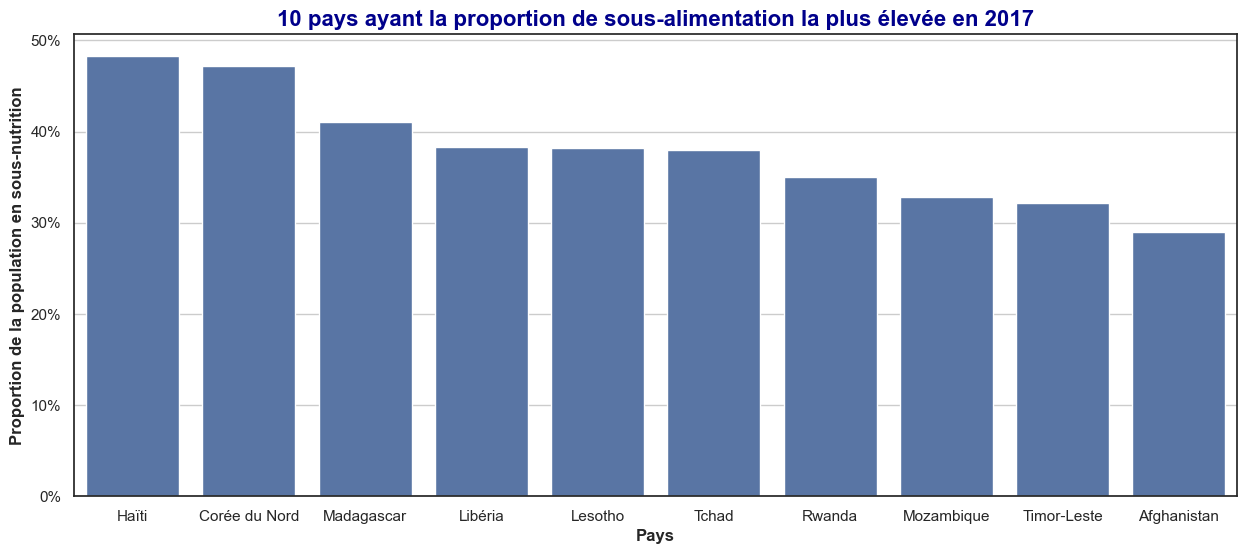

In [66]:
#Graphique des pays en sous alimentation

plt.figure(figsize=(15, 6))

sns.set_theme(style='white')
ax = sns.barplot(data=population_sous_nutrition_2017_pire_pays, x='Zone', y='proportion_sous_nutrition',estimator=sum)
ax.set_title("10 pays ayant la proportion de sous-alimentation la plus élevée en 2017", color='darkblue', fontsize=16, weight='bold')

#Affichage des labels sur les axes
ax.set_xlabel('Pays', weight='bold')

ax.set_ylabel('Proportion de la population en sous-nutrition', weight='bold')

#Affichage de la grille sur l'axe des ordonnés
plt.grid(axis='y')

#Valeurs de l'axe des ordonnées
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5])

#Format de l'axe des ordonnés en pourcentage
ax.set_yticklabels(['{:.0%}'.format(y_values) for y_values in ax.get_yticks()])
plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les pays ayant la proportion de la sous-alimentation la plus élevée se trouvent dans l'hémisphère Sud 
<br />
Haiti se trouve dans les antilles est instable politiquement depuis l'assasssinat de sont président en 2021
<br />
La Corée du Nord est une pays d'Asie ayant un régime autoritaire, il est le pays le plus militarisé au monde
<br />
Madagascar est un pays d'Afrique ayant eu une nouvelle république en 2010
<br />
Le Libéria est un pays d'Afrique
<br />
Le Lesotho est un pays d'Afrique
<br />
Le Tchad est un pays d'Afrique ayant connu une guerre civile entre 2005 et 2010 et il y a une rebellion dans le nord du Tchad
<br />
Le Rwanda est un pays d'Afrique
<br />
Le Mozambique est un pays d'Afrique où 75% des personnes vivent sous le seuil de pauvreté
<br />
Le Timor-Leste est une pays d'Asie où 42% des personnes vivent sous le seuil de pauvreté
<br />
L'Afghanistan est une pays d'Asie qui a connu une guerre entre 2001 et 2021 et où les talibans sont revenus au pouvoir en 2021
</p>
</div>

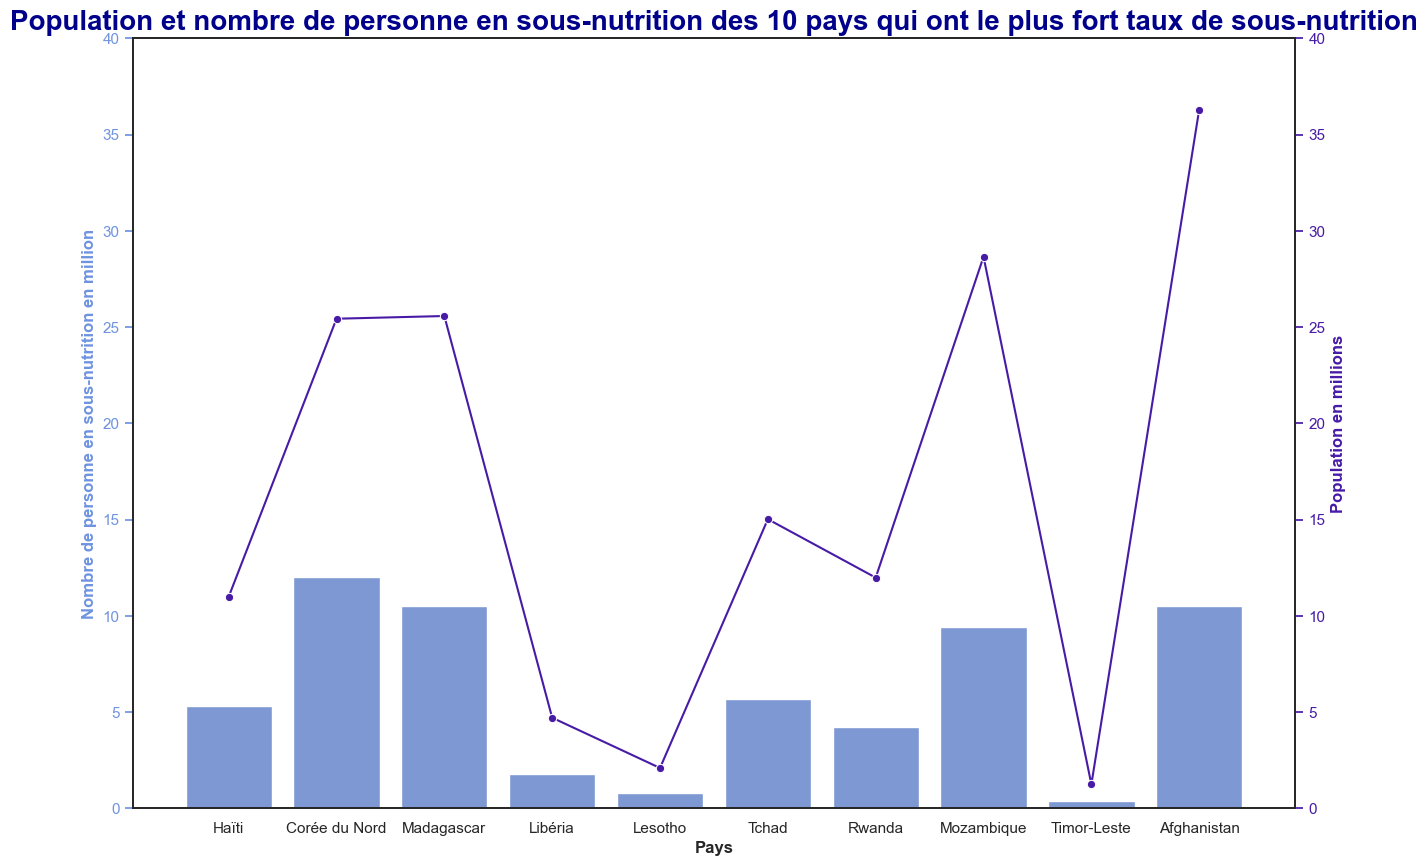

In [67]:
#Graphique contenant le nompbre de personne en sous-nutrition et la population des 10 pays ayant le taux de sous-nutrition le plus élévé

#Conversion des popilations et du nombre de personne en sous nutrition en millions afin que le graphique soit lisible
population_sous_nutrition_2017_pire_pays = population_sous_nutrition_2017_pire_pays.copy()
population_sous_nutrition_2017_pire_pays['sous_nutrition_millions'] = population_sous_nutrition_2017_pire_pays.loc[:,'sous_nutrition'] / 1000000
population_sous_nutrition_2017_pire_pays['population_millions'] = population_sous_nutrition_2017_pire_pays.loc[:,'Population'] / 1000000

fig, ax1 = plt.subplots(figsize=(15, 10))

font_title = {
  'color':  'darkblue',
  'weight': 'bold'
}

ax1.set_title("Population et nombre de personne en sous-nutrition des 10 pays qui ont le plus fort taux de sous-nutrition", fontsize=20, fontdict=font_title)
ax1.set_xlabel('Pays', weight='bold')

# Graphique en barre répésentant le nombre de personne en sous-nutrition
sns.barplot(x='Zone', y='sous_nutrition_millions', data=population_sous_nutrition_2017_pire_pays, ax=ax1, color="#6F93E0")
ax1.set_ylabel('Nombre de personne en sous-nutrition en million', weight='bold')

# Création d'un axe secondaire
ax2 = ax1.twinx()

# Graphique linéaire réprésentant la population
sns.lineplot(x='Zone', y='population_millions', data=population_sous_nutrition_2017_pire_pays, ax=ax2, color='#471BA6', marker='o')
ax2.set_ylabel('Population en millions', weight='bold')

#Echelle des axes des ordonnées
ax1.set_ylim(0, 40)
ax2.set_ylim(0, 40)

#Couleurs des libellés et des valeurs des ordonnées
ax1.yaxis.label.set_color('#6F93E0')
ax2.yaxis.label.set_color('#471BA6')
ax1.tick_params(axis='y', colors='#6F93E0')
ax2.tick_params(axis='y', colors='#471BA6')

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
<b>Haiti</b> a un taux de sous-nutrition de <b>48%</b> mais le nombre de personne en sous-nutrition est inférieur à celui d'<b>Afghanistan</b> qui a un taux de sous-nutrition de <b>29%</b>
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [68]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_par_pays = aide_alimentaire.groupby("Zone")['Aide_alimentaire'].sum().reset_index()


In [69]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_alimentaire_meilleurs_pays = aide_alimentaire_par_pays.sort_values(by='Aide_alimentaire', ascending=False).head(10)

#Dans la liste des pays on remplace République arabe syrienne par Syrie et la République démocratique du Congo par RDC
aide_alimentaire_meilleurs_pays.loc[aide_alimentaire_meilleurs_pays["Zone"] == "République arabe syrienne", "Zone"] = "Syrie"
aide_alimentaire_meilleurs_pays.loc[aide_alimentaire_meilleurs_pays["Zone"] == "République démocratique du Congo", "Zone"] = "RDC"

aide_alimentaire_meilleurs_pays_style = aide_alimentaire_meilleurs_pays.style.format({'Aide_alimentaire':'{:,}'})




print("Pays ayant bénéficié de plus d'aide alimentaire")
aide_alimentaire_meilleurs_pays_style


Pays ayant bénéficié de plus d'aide alimentaire


,Zone,Aide_alimentaire
50,Syrie,"1,858,943,000"
75,Éthiopie,"1,381,294,000"
70,Yémen,"1,206,484,000"
61,Soudan du Sud,"695,248,000"
60,Soudan,"669,784,000"
30,Kenya,"552,836,000"
3,Bangladesh,"348,188,000"
59,Somalie,"292,678,000"
53,RDC,"288,502,000"
43,Niger,"276,344,000"


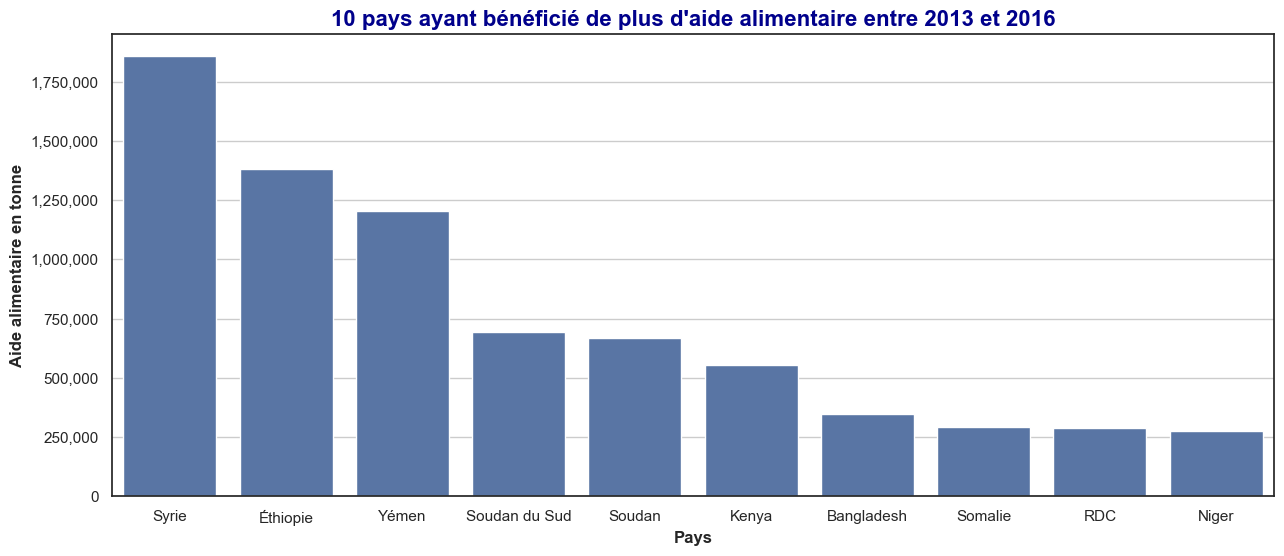

In [70]:
#Graphique des pays ayant bénéficié du plus d'aide

#Conversion de l'aide alimentaire de kilo à tonne afin que la graphique soit plus lisible
aide_alimentaire_meilleurs_pays["Aide_alimentaire_tonne"] = aide_alimentaire_meilleurs_pays.loc[:, 'Aide_alimentaire'] / 1000

plt.figure(figsize=(15, 6))

sns.set_theme(style='white')
ax = sns.barplot(data=aide_alimentaire_meilleurs_pays, x='Zone', y='Aide_alimentaire_tonne',estimator=sum)
plt.title("10 pays ayant bénéficié de plus d'aide alimentaire entre 2013 et 2016", color='darkblue', fontsize=16, weight='bold')
plt.xlabel('Pays', weight='bold')
plt.ylabel(ylabel='Aide alimentaire en tonne', weight='bold')
plt.grid(axis='y')

#Valeurs de l'axe des ordonnées
ax.set_yticks([0,250000,500000,750000,1000000,1250000,1500000,1750000])

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

#Format de l'axe des ordonnés, le séparateur des millers est la virgule
ax.set_yticklabels(['{:,.0f}'.format(y_values) for y_values in ax.get_yticks()])

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les pays ayant le plus bénéficié de l'aide alimentaire sont majoritairement des pays où il y a eu une guerre
<br />
En 2011 il y a eu une famine dans le Corne de l'Afrique à la suite d'une sécheresse dans la région est africaine. Cette famine touchent principalement la Somalie, l'Éthiopie et le Kenya ainsi que le Soudan et le Soudan Sud
<br />
La Syrie est un pays d'Asie où il y a eu guerre civile de 2011 à 2024
<br />
L'Éthiopie est un pays d'Afrique 
<br />
Le Yémen est une pays d'Asie qui connait une guerre civile depuis 2014 qui est la cause d'une famine
<br />
Le Soudan du Sud est un pays d'Afrique ayant connu une guerre civile entre 2013 et 2020
<br />
Le Soudan est un pays d'Afrique qui a connu un conflit armée entre 2011 et 2020 et une révolution entre 2018 et 2019
<br />
Le Kenya est une pays d'Afrique
<br />
Le Bangladesh est un pays d'Asie
<br />
La Somalie est un pays d'Afrique qui connait une guerre civile depuis 2006
<br />
La RDC est un pays d'Afrique qui a connu une rebellion armée entre 2012 et 2013
<br />
Le Niger est un pays d'Afrique qui a connu une coup d'état en 2010
</p>
</div>

In [71]:
#Comparaison de la sous-nutrition et des pays ayant bénéficié de plus d'aide alimentaire
#Le fichier d'aide alimentaire contient les données de 2013 à 2016
#Le fichier de sous-nutrition contient les données de 2013 à 2018

#Récupération des données de sous-nutrition de 2013 à 2016
sous_nutrition_2013_a_2016 = sous_nutrition[
    (sous_nutrition['Année'] == '2012-2014') | (sous_nutrition['Année'] == '2013-2015') | (sous_nutrition['Année'] == '2014-2016') | (sous_nutrition['Année'] == '2015-2017')
]

#Calul du nombre total de personnes en sous-nutrition par pays pour les années 2013 à 2016
sous_nutrition_2013_a_2016_par_pays = sous_nutrition_2013_a_2016.groupby('Zone')['sous_nutrition'].sum().reset_index()

#Merge du dataset contenant les données de sous-nutrition de 2013 à 2016 et du dataset contenant les 10 pays ayant reçu le plus d'aide alimentaire
meilleur_aide_alimentaire_sous_nutrition = pd.merge(left=aide_alimentaire_meilleurs_pays, right=sous_nutrition_2013_a_2016_par_pays, how='left', on='Zone')

#Conversion de la colonne sous_nutrition en millions
meilleur_aide_alimentaire_sous_nutrition['sous_nutrition_millions'] = meilleur_aide_alimentaire_sous_nutrition.loc[:, 'sous_nutrition'] / 1000000
meilleur_aide_alimentaire_sous_nutrition

,Zone,Aide_alimentaire,Aide_alimentaire_tonne,sous_nutrition,sous_nutrition_millions
0,Syrie,1858943000,1858943.0,NaN,NaN
1,Éthiopie,1381294000,1381294.0,93500000.0,93.5
2,Yémen,1206484000,1206484.0,0.0,0.0
3,Soudan du Sud,695248000,695248.0,0.0,0.0
4,Soudan,669784000,669784.0,20200000.0,20.2
5,Kenya,552836000,552836.0,42300000.0,42.3
6,Bangladesh,348188000,348188.0,89700000.0,89.7
7,Somalie,292678000,292678.0,0.0,0.0
8,RDC,288502000,288502.0,NaN,NaN
9,Niger,276344000,276344.0,0.0,0.0


In [72]:
#Graphique représentant la sous-nutrition des pays ayant le plus reçu d'aide alimentaire

#Liste des pays
liste_nom_pays = list(meilleur_aide_alimentaire_sous_nutrition["Zone"])

#Liste contenant le nombre de personne en sous-nutrition des 10 pays recevant le plus d'aide alimentaire
liste_valeur_sous_nutrition = list(meilleur_aide_alimentaire_sous_nutrition["sous_nutrition_millions"])

#Liste contenant l'aide alimantire des 10 pays recevant la meilleure d'aide alimentaire
liste_valeur_aide_alimentaire = list(meilleur_aide_alimentaire_sous_nutrition["Aide_alimentaire_tonne"])

font_title = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':16
}

font_label = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':12
}

fig = make_subplots(specs=[[{"secondary_y": True}]])


fig.add_trace(
     go.Bar(name='Aide alimentaire', x=liste_nom_pays, y=liste_valeur_aide_alimentaire, offsetgroup=1, marker_color = '#6F93E0'),
    secondary_y=False,
)

fig.add_trace(
    go.Bar(name='Nombre de personne en sous-nutrition', x=liste_nom_pays, y=liste_valeur_sous_nutrition, offsetgroup=2, marker_color='#471BA6'),
    secondary_y=True,
)


fig.update_layout(
    title_text="Sous-nutrition des 10 pays ayant reçu le plus d'aide alimentaire",
    title_x= 0.4,
    barmode='group',
    height=800,
    font=font_label,
    legend=dict(x=0.74, y=0.99)
)

fig.update_xaxes(title_text="Pays")

fig.update_yaxes(title_text="Aide alimentaire en tonne", secondary_y=False)
fig.update_yaxes(title_text="Nombre de personne en sous-nutrition en millions", secondary_y=True)

fig.show()


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Pour certains pays le taux de sous-nutrition n'est pas renseigné
<br/>
L'aide alimentaire ne dépend pas du nombre de personne en sous-nutrition mais de la situation geopolitique du pays
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [73]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
aide_alimentaire_par_pays_et_annee = aide_alimentaire.groupby(["Zone","Année"])["Aide_alimentaire"].sum().reset_index()

print("Dataframe contenant l'aide alimentaire groupée par Zone et Année")
aide_alimentaire_par_pays_et_annee.head()


Dataframe contenant l'aide alimentaire groupée par Zone et Année


,Zone,Année,Aide_alimentaire
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [74]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
aide_alimentaire_par_pays = aide_alimentaire.groupby(["Zone"])["Aide_alimentaire"].sum().reset_index()
list_pays_ayant_plus_aide_alimentaire = aide_alimentaire_par_pays.sort_values(by="Aide_alimentaire", ascending=False).head()["Zone"].to_list()

print("Liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire")
list_pays_ayant_plus_aide_alimentaire

Liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [75]:
#On filtre sur le dataframe avec notre liste
pays_ayant_recu_plus_aide_alimentaire = aide_alimentaire_par_pays_et_annee.loc[aide_alimentaire_par_pays_et_annee['Zone'].isin(list_pays_ayant_plus_aide_alimentaire),:]

#Dans le dataset on remplace République arabe syrienne par Syrie
pays_ayant_recu_plus_aide_alimentaire.loc[pays_ayant_recu_plus_aide_alimentaire["Zone"] == "République arabe syrienne", "Zone"] = "Syrie"

#Conversion de l'aide alimentaire en tonne
pays_ayant_recu_plus_aide_alimentaire = pays_ayant_recu_plus_aide_alimentaire.copy()
pays_ayant_recu_plus_aide_alimentaire['Aide_alimentaire_tonne'] = pays_ayant_recu_plus_aide_alimentaire.loc[:,'Aide_alimentaire'] / 1000
pays_ayant_recu_plus_aide_alimentaire.sort_values(by='Aide_alimentaire')

,Zone,Année,Aide_alimentaire,Aide_alimentaire_tonne
191,Soudan,2015,17650000,17650.0
194,Soudan du Sud,2015,48308000,48308.0
215,Yémen,2014,103840000,103840.0
160,Syrie,2016,118558000,118558.0
192,Soudan du Sud,2013,196330000,196330.0
227,Éthiopie,2015,203266000,203266.0
214,Yémen,2013,264764000,264764.0
190,Soudan,2014,321904000,321904.0
189,Soudan,2013,330230000,330230.0
216,Yémen,2015,372306000,372306.0


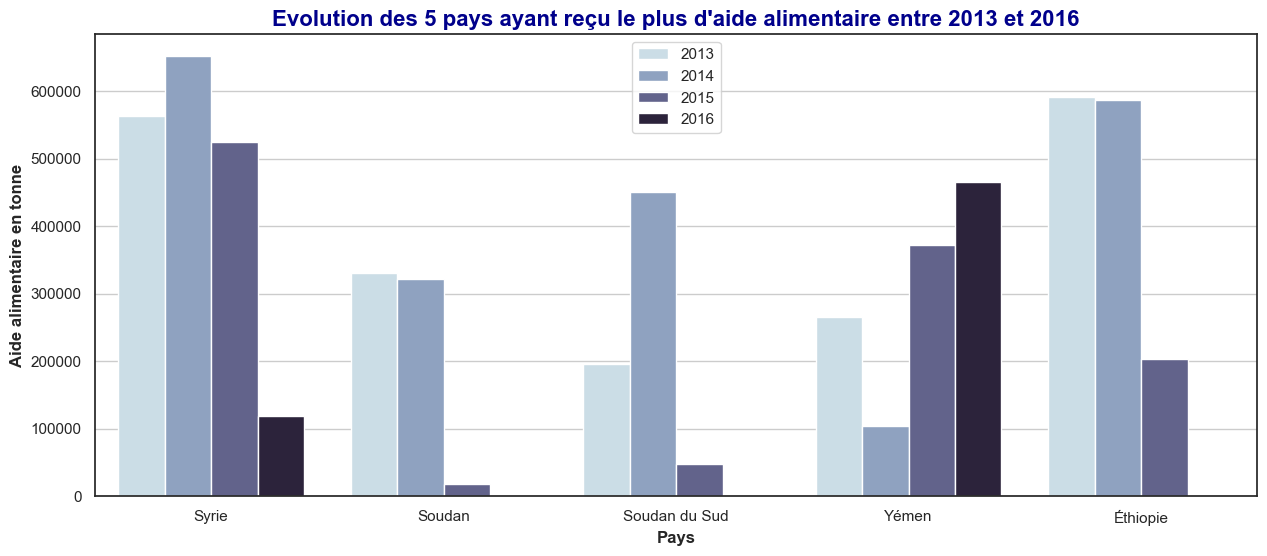

In [76]:
# Affichage des pays avec l'aide alimentaire par année

plt.figure(figsize=(15, 6))
sns.set_theme(style='white')
sns.barplot(data=pays_ayant_recu_plus_aide_alimentaire, x='Zone', y='Aide_alimentaire_tonne', hue='Année', estimator=sum, palette= "ch:s=.25,rot=-.25")
plt.title("Evolution des 5 pays ayant reçu le plus d'aide alimentaire entre 2013 et 2016",  color='darkblue', fontsize=16, weight='bold')
plt.xlabel('Pays', weight='bold')
plt.ylabel('Aide alimentaire en tonne', weight='bold')
plt.grid(axis='y')
plt.legend(loc='upper center')

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les 5 pays ayant reçu le plus d'aide alimentaire entre 2013 et 2016 ont connus des guerres civiles pendant ces période pourtant en 2016 l'aide alimentaire n'a été fourni que pour la Syrie et le Yémen.
<br />
On constate une baisse des aides alimentaire pour l'année 2016 pour les 5 pays ayant reçu le plus d'aide
</p>
</div>

In [77]:
#Dataset réprésentant les aides alimantaire par année
aide_alimentaire_by_annee = aide_alimentaire.groupby("Année")["Aide_alimentaire"].sum().reset_index()

#Conversion de l'aide alimentaire en tonnne
aide_alimentaire_by_annee = aide_alimentaire_by_annee.copy()
aide_alimentaire_by_annee["Aide_alimentaire_tonne"] = aide_alimentaire_by_annee["Aide_alimentaire"] / 1000
aide_alimentaire_by_annee

,Année,Aide_alimentaire,Aide_alimentaire_tonne
0,2013,4165674000,4165674.0
1,2014,3939152000,3939152.0
2,2015,2187507000,2187507.0
3,2016,743568000,743568.0


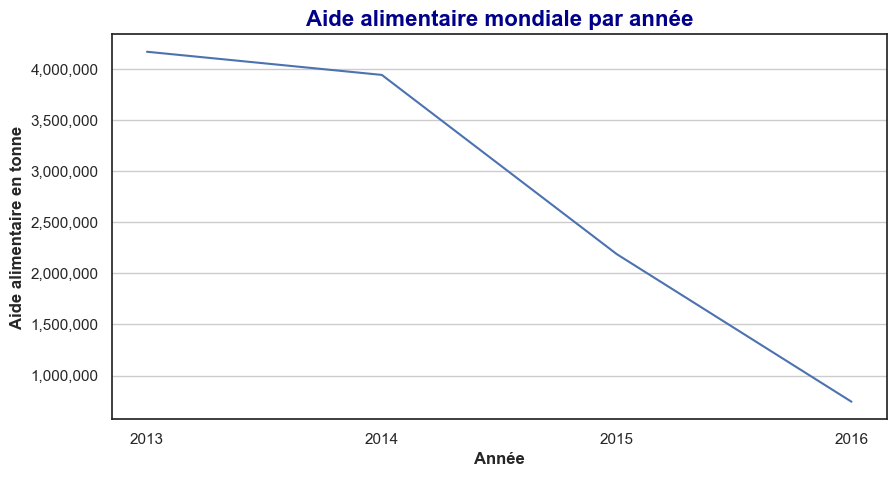

In [78]:
#Graphique réprésentant les aides alimentaires mondiales entre 2013 et 2016
ax = sns.lineplot(data=aide_alimentaire_by_annee, x="Année", y="Aide_alimentaire_tonne")
ax.figure.set_size_inches(10, 5)

ax.set_title("Aide alimentaire mondiale par année", color='darkblue', fontsize=16, weight='bold')


#Affichage des labels sur les axes
ax.set_xlabel('Année', weight='bold')
ax.set_ylabel('Aide alimentaire en tonne', weight='bold')

#Affichage de la grille sur l'axe des ordonnés
plt.grid(axis='y')

#Valeurs de l'axe des ordonnées
ax.set_xticks([2013, 2015, 2014, 2016])

#Valeurs de l'axe des ordonnées
ax.set_yticks([1000000,1500000,2000000,2500000,3000000,3500000,4000000])

#Format de l'axe des ordonnées
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.set_yticklabels(['{:,.0f}'.format(y_values) for y_values in ax.get_yticks()])

plt.show()


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Il y a une diminution de l'aide alimentaire mondiale entre 2013 et 2016
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [79]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_alimentaire_kcal_personne_jour_pays = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()
dispo_alimentaire_kcal_personne_jour_pays.head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0
5,Angola,2474.0
6,Antigua-et-Barbuda,2416.0
7,Arabie saoudite,3255.0
8,Argentine,3226.0
9,Arménie,2924.0


In [80]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
pays_ayant_moins_dispo_alimentaire_par_personne = dispo_alimentaire_kcal_personne_jour_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=True).head(10)
print("10 pays ayant le moins de dispo alimentaire")
pays_ayant_moins_dispo_alimentaire_par_personne

10 pays ayant le moins de dispo alimentaire


,Zone,Disponibilité alimentaire (Kcal/personne/jour)
128,République centrafricaine,1879.0
166,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
133,République populaire démocratique de Corée,2093.0
151,Tchad,2109.0
167,Zimbabwe,2113.0
114,Ouganda,2126.0
154,Timor-Leste,2129.0


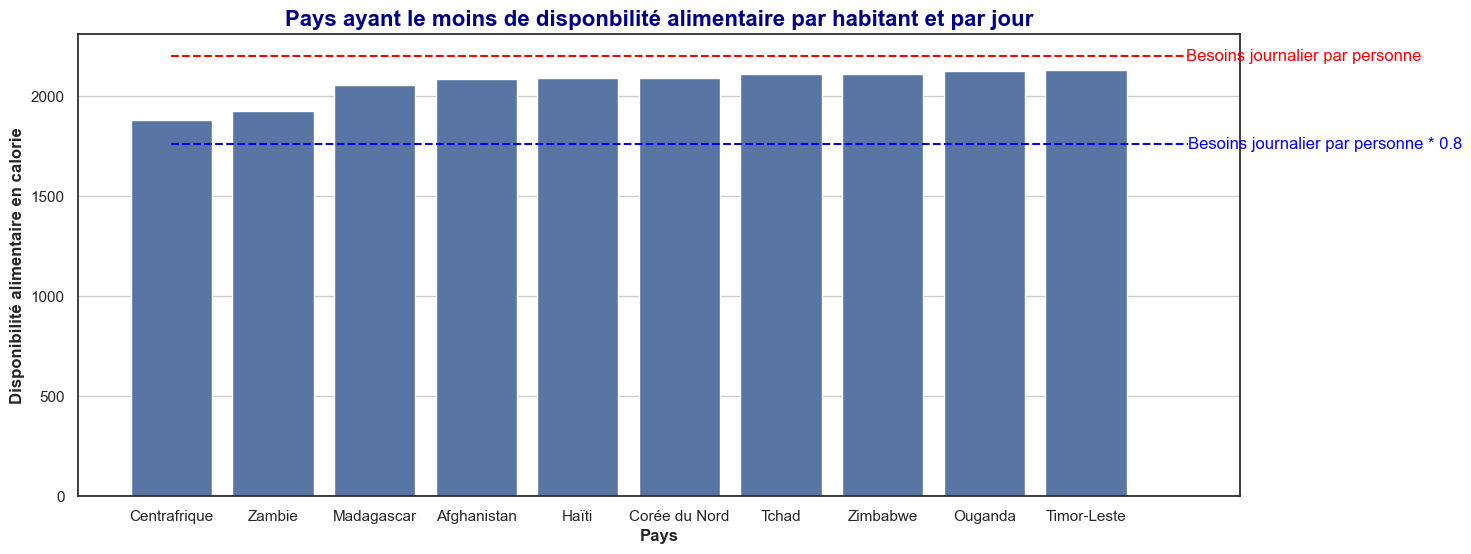

In [81]:
#Graphique en bar des pays ayant le moins de disponibilité alimentaire par en kcal par habitant et par jour


#Dans le dataset on remplace République populaire démocratique de Corée par Corée du Nord et République centrafricaine par Centrafrique
pays_ayant_moins_dispo_alimentaire_par_personne.loc[pays_ayant_moins_dispo_alimentaire_par_personne["Zone"] == "République populaire démocratique de Corée", "Zone"] = "Corée du Nord"
pays_ayant_moins_dispo_alimentaire_par_personne.loc[pays_ayant_moins_dispo_alimentaire_par_personne["Zone"] == "République centrafricaine", "Zone"] = "Centrafrique"

plt.figure(figsize=(15, 6))
sns.set_theme(style='white')
sns.barplot(data=pays_ayant_moins_dispo_alimentaire_par_personne, x='Zone', y='Disponibilité alimentaire (Kcal/personne/jour)', estimator=sum)

plt.title("Pays ayant le moins de disponbilité alimentaire par habitant et par jour",  color='darkblue', fontsize=16, weight='bold')
plt.xlabel('Pays', weight='bold')
plt.ylabel('Disponibilité alimentaire en calorie', weight='bold')
plt.grid(axis='y')

#ligne repésentant les besoins journaliers par personne
plt.hlines(y=nourriture_kcal_par_jour_par_personne, xmin=0, xmax=10, colors="red", linestyles='dashed')
plt.text(12.3, nourriture_kcal_par_jour_par_personne, 'Besoins journalier par personne', ha='right', va='center', color='red')

#ligne repésentant les besoins journaliers par personne
plt.hlines(y=0.8 * nourriture_kcal_par_jour_par_personne, xmin=0, xmax=10, colors="blue", linestyles='dashed')
plt.text(12.7, 0.8 * nourriture_kcal_par_jour_par_personne, 'Besoins journalier par personne * 0.8', ha='right', va='center', color='blue')


plt.show()

In [82]:
print("6 des 10 pays ayant le moins de disponibilité alimentaire est en sous-nutrition")

print("Analyse de la sous-nutrition des 4 autres pays qui ont le moins de disponibilité alimentaire")
display(sous_nutrition_orig[(sous_nutrition_orig['Zone'] == "République centrafricaine") | (sous_nutrition_orig['Zone'] == "Zambie") | (sous_nutrition_orig['Zone'] == "Zimbabwe") | (sous_nutrition_orig['Zone'] == "Ouganda")])

print("Analyse de l'aide alimentaire apportée aux 4 autres pays qui ont le moins de disponibilité alimentaire")
#On reinitialise l'index dans le dataframe contenant l'aide alimentaire par pays croissant afin de savoir dans si les pays sont ceux qui reçoivent le plus d'aide alimentaire
aide_alimentaire_par_pays_sort_by_aide = aide_alimentaire_par_pays.sort_values(by="Aide_alimentaire", ascending=False).reset_index(drop=True)
a =aide_alimentaire_par_pays_sort_by_aide[(aide_alimentaire_par_pays_sort_by_aide['Zone'] == "République centrafricaine") | (aide_alimentaire_par_pays_sort_by_aide['Zone'] == "Zambie") | (aide_alimentaire_par_pays_sort_by_aide['Zone'] == "Zimbabwe") | (aide_alimentaire_par_pays_sort_by_aide['Zone'] == "Ouganda")]
a

6 des 10 pays ayant le moins de disponibilité alimentaire est en sous-nutrition
Analyse de la sous-nutrition des 4 autres pays qui ont le moins de disponibilité alimentaire


,Zone,Année,Valeur
804,Ouganda,2012-2014,NaN
805,Ouganda,2013-2015,NaN
806,Ouganda,2014-2016,NaN
807,Ouganda,2015-2017,NaN
808,Ouganda,2016-2018,NaN
809,Ouganda,2017-2019,NaN
906,République centrafricaine,2012-2014,NaN
907,République centrafricaine,2013-2015,NaN
908,République centrafricaine,2014-2016,NaN
909,République centrafricaine,2015-2017,NaN


Analyse de l'aide alimentaire apportée aux 4 autres pays qui ont le moins de disponibilité alimentaire


,Zone,Aide_alimentaire
27,République centrafricaine,66610000
29,Ouganda,64622000
30,Zimbabwe,62570000
65,Zambie,3026000


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les pays ayant le moins de disponibilité alimentaire ne couvrent pas les dépenses alimentaire d'un adulte par jour et se situent sur les continents Africains et Asiatique
<br />
On constate que parmi les pays en ayant le moins de disponibilité alimentaire 6 ont des taux de sous-nutrition les plus élevé <b>(Haïti, Corée du Nord, Madagascar, Tchad, Timor-Lesther et l'Afghanistan)</b>
<br />
Les données de sous-nutrition n'ont pas été fournie pour les 4 autres pays qui sont <b> la Centrafrique, la Zambie, le Zimbabwe et l'Ouganda</b> mais les données d'aide alimentaire ont était fourni:
<br />   
<b> La Centrafrique, le Zimbabwe et l'Ouganda</b> sont parmi les 28ème à 31ème pays ayant reçu le plus d'aide alimentaire parmi les 76 pays, <b>la Zambie</> est l'un des 10 pays ayant reçu le moins d'aide alimentaire
<br />
</p> 
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [83]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
pays_ayant_plus_dispo_alimentaire_par_personne = dispo_alimentaire_kcal_personne_jour_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).head(10)
pays_ayant_plus_dispo_alimentaire_par_personne

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770.0
16,Belgique,3737.0
159,Turquie,3708.0
171,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
168,Égypte,3518.0
4,Allemagne,3503.0


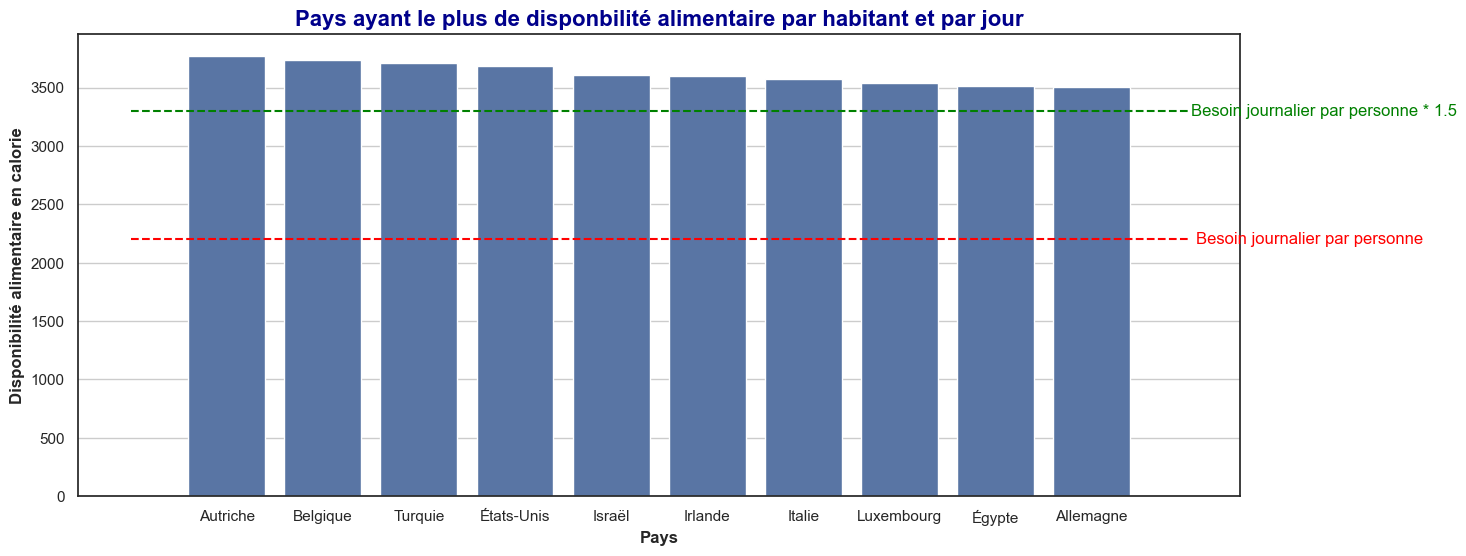

In [84]:
#Graphique en bar des pays ayant le plus de disponibilité alimentaire par en kcal par habitant et par jour

#Dans le dataset on remplace États-unis d'Amérique par États-unis
pays_ayant_plus_dispo_alimentaire_par_personne.loc[pays_ayant_plus_dispo_alimentaire_par_personne["Zone"] == "États-Unis d'Amérique", "Zone"] = "États-Unis"

plt.figure(figsize=(15, 6))
sns.set_theme(style='white')
sns.barplot(data=pays_ayant_plus_dispo_alimentaire_par_personne, x='Zone', y='Disponibilité alimentaire (Kcal/personne/jour)', estimator=sum)

plt.title("Pays ayant le plus de disponbilité alimentaire par habitant et par jour",  color='darkblue', fontsize=16, weight='bold')
plt.xlabel('Pays', weight='bold')
plt.ylabel('Disponibilité alimentaire en calorie', weight='bold')
plt.grid(axis='y')

#Ligne représentant les besoins journaliers par personne
plt.hlines(y=nourriture_kcal_par_jour_par_personne, xmin=-1, xmax=10, colors="red", linestyles='dashed')
plt.text(12.5, nourriture_kcal_par_jour_par_personne, 'Besoin journalier par personne ', ha='right', va='center', color='red')

#Ligne représentant les besoins journaliers par personne * 1.5
plt.hlines(y=1.5 * nourriture_kcal_par_jour_par_personne, xmin=-1, xmax=10, colors="green", linestyles='dashed')
plt.text(12.8, 1.5 * nourriture_kcal_par_jour_par_personne, 'Besoin journalier par personne * 1.5', ha='right', va='center', color='green')


plt.show()

In [85]:
print("Les pays ayant le plus d'aide alimentaire se trouve majoritairement en Europe")
print("Neanmoins parmi ces 10 pays il y en a se trouvant en Asie et Afrique, la Turquie, Israël et l'Égypte")

print("Analyse de la sous-nutrition de ces pays")
display(sous_nutrition_orig[(sous_nutrition_orig['Zone'] == "Turquie") | (sous_nutrition_orig['Zone'] == "Israël") | (sous_nutrition_orig['Zone'] == "Égypte")])

Les pays ayant le plus d'aide alimentaire se trouve majoritairement en Europe
Neanmoins parmi ces 10 pays il y en a se trouvant en Asie et Afrique, la Turquie, Israël et l'Égypte
Analyse de la sous-nutrition de ces pays


,Zone,Année,Valeur
312,Égypte,2012-2014,4.4
313,Égypte,2013-2015,4.3
314,Égypte,2014-2016,4.2
315,Égypte,2015-2017,4.5
316,Égypte,2016-2018,4.6
317,Égypte,2017-2019,4.6
540,Israël,2012-2014,NaN
541,Israël,2013-2015,NaN
542,Israël,2014-2016,NaN
543,Israël,2015-2017,NaN


In [86]:
print("Les données de sous-nutrition ne sont pas renseignée pour la Turquie, Israël et l'Égypte")
#Calcul du taux de sous-nutrition de l'Egypte
taux_sous_nutrition_egypte_20017 = population_sous_nutrition_2017[population_sous_nutrition_2017["Zone"] == "Égypte"]["proportion_sous_nutrition"]
print("En 2017 la taux de sous-nutrition en Egype était de {:.2%}".format(taux_sous_nutrition_egypte_20017.values[0]))

Les données de sous-nutrition ne sont pas renseignée pour la Turquie, Israël et l'Égypte
En 2017 la taux de sous-nutrition en Egype était de 4.77%


In [87]:
print("Analyse de l'aide alimentaire pour la Turquie, Israël et l'Égypte")
aide_alimentaire_par_pays[(aide_alimentaire_par_pays['Zone'] == "Turquie") | (aide_alimentaire_par_pays['Zone'] == "Israël") | (aide_alimentaire_par_pays['Zone'] == "Égypte")]

Analyse de l'aide alimentaire pour la Turquie, Israël et l'Égypte


,Zone,Aide_alimentaire
73,Égypte,1122000


In [88]:
print("Seule l'aide alimentaire de accordée à l'Egypte est présente")
print("Affichage des 5 pays recevant le moins d'aide alimentaire")
aide_alimentaire_par_pays.sort_values(by="Aide_alimentaire", ascending=True).head()

Seule l'aide alimentaire de accordée à l'Egypte est présente
Affichage des 5 pays recevant le moins d'aide alimentaire


,Zone,Aide_alimentaire
5,Bolivie (État plurinational de),6000
24,Géorgie,70000
67,Timor-Leste,116000
69,Vanuatu,802000
73,Égypte,1122000


In [89]:
print("L'Egypte est l'un des pays qui reçoit le moins d'aide alimentaire")

L'Egypte est l'un des pays qui reçoit le moins d'aide alimentaire


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les pays ayant le plus de disponibilité alimentaire couvrent les dépenses alimentaire moyenne d'un adulte par jour et se trouvent majoritairement en Europe et en Amerique du Nord.
<br/>
Neanmoins il y a 3 pays se trouvant en Asie et Afrique qui ont des disponibilité alimenaire qui couvrent les dépeneses alimentaire d'un adulte <b>la Turquie, Israël et l'Égypte</b>
<br/>
Nous n'avons pas les données de la sous-nutrition et de l'aide alimentaire pour la Turquie et Israël 
<br/>
L'Égypte est l'un des pays recevant peu d'aide alimentaire et avait taux de sous-nutrition de 5% en 2017 et ce qui est faible
<br/>
Malgré les conflits militaire la Turquie, Israël et l'Égypte parviennent à avoir des produits alimentaire permettant de nourrir sa population
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [90]:
#création d'un dataframe avec uniquement la Thaïlande 
sous_nutrition_2017_thailande = sous_nutrition_2017[sous_nutrition_2017['Zone'] == "Thaïlande"]
population_2017_thailande = population_2017[population_2017['Zone'] == "Thaïlande"]
sous_nutrition_population_2017_thailande = pd.merge(left=sous_nutrition_2017_thailande, right=population_2017_thailande, on="Zone", how="inner")
sous_nutrition_population_2017_thailande.rename(columns={'Année_x': 'Année_sous_nutrition', 'Année_y': 'Année_population'}, inplace=True)

print("Dataset contenant les données de la Thaïlande pour l'année 2017")
sous_nutrition_population_2017_thailande

Dataset contenant les données de la Thaïlande pour l'année 2017


,Zone,Année_sous_nutrition,sous_nutrition,Année_population,Population
0,Thaïlande,2016-2018,6200000.0,2017,69209810.0


In [91]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_thailande_2017 = sous_nutrition_population_2017_thailande['sous_nutrition'][0]
population_thailande_2017 = sous_nutrition_population_2017_thailande['Population'][0]
taux_sous_nutrition_thailande_2017 = sous_nutrition_thailande_2017 / population_thailande_2017

print("Le taux de sous-nutrition en Thailande est de : {:.2%}".format(taux_sous_nutrition_thailande_2017))

Le taux de sous-nutrition en Thailande est de : 8.96%


In [92]:
# On calcule la proportion exportée en fonction de la proportion
dispo_alimentaire_manioc_thailande = dispo_alimentaire[(dispo_alimentaire["Zone"] == "Thaïlande") & (dispo_alimentaire["Produit"] == "Manioc")]
exportation_manioc_thailande = dispo_alimentaire_manioc_thailande["Exportations - Quantité"].values[0]
production_manioc_thailande = dispo_alimentaire_manioc_thailande["Production"].values[0]

print("L'exportation du manioc en Thaïlande est de : {:,.0f} kg".format(exportation_manioc_thailande))
print("La production de manioc en Thaïlande est de : {:,.0f} kg".format(production_manioc_thailande))
print("La Thaïlande exporte {:.2%} du manioc qu'elle produit".format(exportation_manioc_thailande/production_manioc_thailande))



L'exportation du manioc en Thaïlande est de : 25,214,000 kg
La production de manioc en Thaïlande est de : 30,228,000 kg
La Thaïlande exporte 83.41% du manioc qu'elle produit


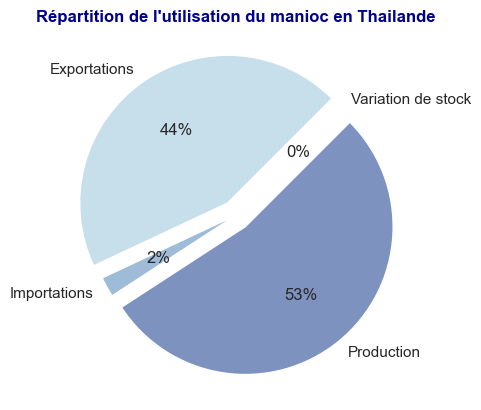

In [93]:
#Utilisation du manioc en Thailande
manioc_thailande_utilisation = dispo_alimentaire_manioc_thailande[['Exportations - Quantité','Importations - Quantité','Production','Variation de stock']]

plt.pie(
    x=manioc_thailande_utilisation.melt()["value"], 
    startangle = 45,
    labels=["Exportations","Importations","Production","Variation de stock"],
    colors=sns.color_palette("ch:s=.25,rot=-.25"),
    autopct='%.0f%%', 
    explode=(0.1, 0,0.1, 0),
)

plt.title("Répartition de l'utilisation du manioc en Thailande",weight="bold", color='darkblue')
plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Une grande partie de la production de manioc en Thailande est utilisée pour l'exportation alors qu'elle peut être utilisée pour l'alimentation de la population
</p>
</div>

In [94]:
#Disponibilité interne du manioc en Thailande
manioc_thailande_utilisation = dispo_alimentaire_manioc_thailande[['Nourriture','Aliments pour animaux','Pertes','Semences','Traitement','Autres Utilisations']]
manioc_thailande_utilisation

,Nourriture,Aliments pour animaux,Pertes,Semences,Traitement,Autres Utilisations
13809,871000.0,1800000.0,1511000.0,0.0,0.0,2081000.0


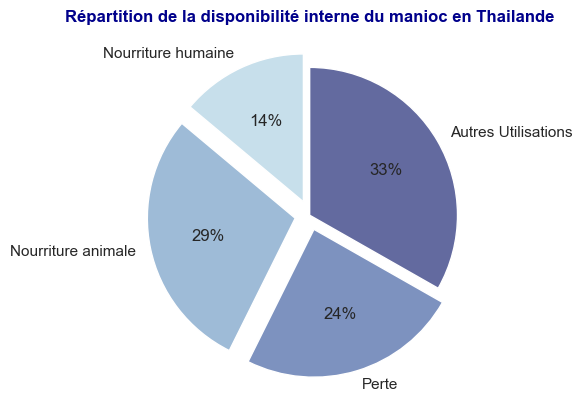

In [95]:
#Graphique représentant l'utilisation du manioc en Thailande
#Nous ne présentons par la semence et le traitement dans ce graphique car il sont de 0 pour le manioc en Thailande
manioc_thailande_utilisation = dispo_alimentaire_manioc_thailande[['Nourriture','Aliments pour animaux','Pertes','Autres Utilisations']]
plt.pie(
    x=manioc_thailande_utilisation.melt()["value"], 
    startangle= 90,
    labels=["Nourriture humaine","Nourriture animale","Perte","Autres Utilisations"],
    colors=sns.color_palette("ch:s=.25,rot=-.25"),
    autopct='%.0f%%', explode=(0.1, 0.1,0.1, 0),
)

plt.title("Répartition de la disponibilité interne du manioc en Thailande",weight="bold", color='darkblue')
plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Seul <b>14%</b> du manioc de Thailande est utilisé pour la nourriture humaines
</p>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
La Thaïlande exporte <b>83%</b> de sa production de manioc pourtant son taux de sous-nutrition est de <b>9%</b> qui est supérieur au taux de sous-nuitrion de la population mondiale qui est de <b>7%</b>
<br />
<b>1.8 millions de kilos</b> de manioc sont utilisé pour les animaux contre <b>871 000 kilos</b> pour les humains
<br />
Les pertes de manioc en Thailande sont de <b>1 511 000 kilos</b> ce qui représente <b>25%</b> de sa disponibilité 
<br />
La disponibilité intérieure de la Thailande en Manioc est de <b>6000 tonnes</b>
<br />
Plus de manioc pourrait être utilisé pour la nourriture des humains et il faudrait mieux gerer les pertes afin de baisser le nombre de personne qui sont en état de sous-nutrition.
</p>
</div>

In [96]:
#Calcul du nombre de kcal disponible en Thailande en 2017
dispo_alimentaire_thailande_par_kcal_2017 = dispo_alimentaire_par_kcal_2017[(dispo_alimentaire_par_kcal_2017["Zone"] == "Thaïlande")]

dispo_alimentaire_par_kcal_jour_2017_thailande_serie =  dispo_alimentaire_thailande_par_kcal_2017['Population'] * dispo_alimentaire_thailande_par_kcal_2017['Disponibilité alimentaire (Kcal/personne/jour)']
dispo_kcal_jour_thailande_2017 = dispo_alimentaire_par_kcal_jour_2017_thailande_serie.sum()

print('Les calories disponibles en Thailande par jour en 2017 sont de {:,.0f}'.format(dispo_kcal_jour_thailande_2017))

Les calories disponibles en Thailande par jour en 2017 sont de 192,749,320,850


In [97]:
#Calcul du nombre de personne pouvant être nourris en Thailande en 2017

humain_pouvant_etre_nourris_thailande_2017 = dispo_kcal_jour_thailande_2017 / nourriture_kcal_par_jour_par_personne
population_2017_thailande_numeric = population_2017_thailande['Population'].values[0]

print("Le nombre de personne pouvant être nourris en Thailande en 2017 est de {:,.0f}".format(humain_pouvant_etre_nourris_thailande_2017),"pour une nombre d'humain total en Thailande en 2017 de","{:,.0f}".format(population_2017_thailande_numeric))

print("La proportion de personne pouvant être nourris en 2017 en Thailande est de {:.2%}".format(humain_pouvant_etre_nourris_thailande_2017 / population_2017_thailande_numeric))

Le nombre de personne pouvant être nourris en Thailande en 2017 est de 87,613,328 pour une nombre d'humain total en Thailande en 2017 de 69,209,810
La proportion de personne pouvant être nourris en 2017 en Thailande est de 126.59%


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
En 2017 les besoins alimentaires de la Thailande sont couverts mais la sous-nutrition est plus elevée que la moyenne dans ce pays.
<br>
Une suggestion pour diminuer le sous-nutrition est de revoir la réparition du <b>Manioc</b>, de moins l'exporter et de plus l'utiliser pour la nourriture humaine.
</p>
</div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse complémentaires</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.1 - Exemple de la Thaïlande pour les céréales
</h3>
</div>

In [98]:
#Etudes des céréales les plus consommées
liste_nom_cereales = ['Riz (Eq Blanchi)', 'Maïs', 'Blé']

In [99]:
#Récupération de la disponibilite interne des céréales en Thailande
dispo_alimentaire_cereales_thailande = dispo_alimentaire.loc[(dispo_alimentaire["Zone"] == "Thaïlande") & (dispo_alimentaire['Produit'].isin(liste_nom_cereales)),:]
dispo_alimentaire_cereales_thailande_groupby_cereales = dispo_alimentaire_cereales_thailande.groupby(["Produit"], sort=False)[['Nourriture','Aliments pour animaux','Pertes','Semences','Traitement','Autres Utilisations']].sum().reset_index()

#Conversion des quantité des kilos vers les tonnes pour que le graphique soit plus lisible
dispo_alimentaire_cereales_thailande_groupby_cereales["Nourriture_tonne"] = dispo_alimentaire_cereales_thailande_groupby_cereales["Nourriture"] / 1000
dispo_alimentaire_cereales_thailande_groupby_cereales["Aliments_pour_animaux_tonne"] = dispo_alimentaire_cereales_thailande_groupby_cereales["Aliments pour animaux"] / 1000
dispo_alimentaire_cereales_thailande_groupby_cereales["Pertes_tonne"] = dispo_alimentaire_cereales_thailande_groupby_cereales["Pertes"] / 1000
dispo_alimentaire_cereales_thailande_groupby_cereales["Semences_tonne"] = dispo_alimentaire_cereales_thailande_groupby_cereales["Semences"] / 1000
dispo_alimentaire_cereales_thailande_groupby_cereales["Traitement_tonne"] = dispo_alimentaire_cereales_thailande_groupby_cereales["Traitement"] / 1000
dispo_alimentaire_cereales_thailande_groupby_cereales["Autres_utilisations_tonne"] = dispo_alimentaire_cereales_thailande_groupby_cereales["Autres Utilisations"] / 1000


print("Disponibilité alimentaire des céréales en Thaïlande")
dispo_alimentaire_cereales_thailande_groupby_cereales

Disponibilité alimentaire des céréales en Thaïlande


,Produit,Nourriture,Aliments pour animaux,Pertes,Semences,Traitement,Autres Utilisations,Nourriture_tonne,Aliments_pour_animaux_tonne,Pertes_tonne,Semences_tonne,Traitement_tonne,Autres_utilisations_tonne
0,Blé,733000.0,1130000.0,0.0,0.0,20000.0,0.0,733.0,1130.0,0.0,0.0,20.0,0.0
1,Maïs,681000.0,3724000.0,105000.0,24000.0,144000.0,0.0,681.0,3724.0,105.0,24.0,144.0,0.0
2,Riz (Eq Blanchi),7677000.0,2405000.0,1786000.0,606000.0,1130000.0,0.0,7677.0,2405.0,1786.0,606.0,1130.0,0.0


In [100]:
#Modification de l'ordre des lignes dans l'ordre suivant riz, mais, blé
new_order = [2, 1, 0]
dispo_alimentaire_cereales_thailande_groupby_cereales = dispo_alimentaire_cereales_thailande_groupby_cereales.reindex(new_order)
dispo_alimentaire_cereales_thailande_groupby_cereales

,Produit,Nourriture,Aliments pour animaux,Pertes,Semences,Traitement,Autres Utilisations,Nourriture_tonne,Aliments_pour_animaux_tonne,Pertes_tonne,Semences_tonne,Traitement_tonne,Autres_utilisations_tonne
2,Riz (Eq Blanchi),7677000.0,2405000.0,1786000.0,606000.0,1130000.0,0.0,7677.0,2405.0,1786.0,606.0,1130.0,0.0
1,Maïs,681000.0,3724000.0,105000.0,24000.0,144000.0,0.0,681.0,3724.0,105.0,24.0,144.0,0.0
0,Blé,733000.0,1130000.0,0.0,0.0,20000.0,0.0,733.0,1130.0,0.0,0.0,20.0,0.0


In [101]:
#Graphique en barre représentant la disponibilité interne de chaque céréales en Thailande

#Liste des nom des céréales
liste_nom_cereales = list(dispo_alimentaire_cereales_thailande_groupby_cereales['Produit'])

#Liste de la quantité des céréales utilisée pour la nourriture humaine
liste_nourriture_cereales = list(dispo_alimentaire_cereales_thailande_groupby_cereales['Nourriture_tonne'])

#Liste de la quantité des céréales utilisée pour la nourriture animale
liste_aliments_animaux_cereales = list(dispo_alimentaire_cereales_thailande_groupby_cereales['Aliments_pour_animaux_tonne'])

#Liste de la quantité des céréales perdus
liste_pertes_cereales = list(dispo_alimentaire_cereales_thailande_groupby_cereales['Pertes_tonne'])

#Liste de la quantité des céréales utilisée pour la semence
liste_semences_cereales = list(dispo_alimentaire_cereales_thailande_groupby_cereales['Semences_tonne'])

#Liste de la quantité des céréales utilisée pour le traitement
liste_traitement_cereales = list(dispo_alimentaire_cereales_thailande_groupby_cereales['Traitement_tonne'])

#Liste de la quantité des céréales utilisée pour d'autres utilisation
liste_autre_utilisation_cereales = list(dispo_alimentaire_cereales_thailande_groupby_cereales['Autres_utilisations_tonne'])

#Graphique
font_title = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':16
}

font_label = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':12
}

fig_dispo_interne_cereales_thailande = go.Figure(
    data=[
        go.Bar(name='Nourriture', x=liste_nom_cereales, y=liste_nourriture_cereales, marker_color='#2B1F3E'),
        go.Bar(name='Aliments pour animaux', x=liste_nom_cereales, y=liste_aliments_animaux_cereales, marker_color='#494373'),
        go.Bar(name='Pertes', x=liste_nom_cereales, y=liste_pertes_cereales, marker_color='#636A9F'),
        go.Bar(name='Semences', x=liste_nom_cereales, y=liste_semences_cereales, marker_color='#7D92BF'),
        go.Bar(name='Traitement', x=liste_nom_cereales, y=liste_traitement_cereales, marker_color='#9EBBD7'),
        go.Bar(name='Autres utilisations', x=liste_nom_cereales, y=liste_autre_utilisation_cereales, marker_color='#C7DFEB')
    ],
    layout = go.Layout(
        title = go.layout.Title(text = "Répartition de la disponibilité interne des céréales en Thailande", font=font_title, x = 0.4),
        xaxis = go.layout.XAxis(title = 'Céréales', color='black'),
        yaxis = go.layout.YAxis(title = 'Aliments en tonne', color='black')
    )
)

fig_dispo_interne_cereales_thailande.update_layout(
    barmode='group',
    height=600,
    width=800,
    font=font_label,
    legend=dict(x=0.67, y=0.99)
)
fig_dispo_interne_cereales_thailande.show()


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
<b>Le riz</b> est la céréale la plus consommée en Thailande par les humains
<br />
Le mais est la céréale la plus consommée par les animaux en Thailande
<br />
Le blé est plus consommé par les animaux que les humains
</p>
</div>

In [102]:
#Calcul de l'utilisation des céréales en Thailande
utilisation_cereales_thailande_groupby_cereales = dispo_alimentaire_cereales_thailande.groupby("Produit")[['Exportations - Quantité','Importations - Quantité','Production','Variation de stock']].sum().reset_index()

#Conversion des quantité des kilos vers les tonnes pour que le graphique soit plus lisible
utilisation_cereales_thailande_groupby_cereales["Exportations_tonne"] = utilisation_cereales_thailande_groupby_cereales["Exportations - Quantité"] / 1000
utilisation_cereales_thailande_groupby_cereales["Importations_tonne"] = utilisation_cereales_thailande_groupby_cereales["Importations - Quantité"] / 1000
utilisation_cereales_thailande_groupby_cereales["Production_tonne"] = utilisation_cereales_thailande_groupby_cereales["Production"] / 1000
utilisation_cereales_thailande_groupby_cereales["Variation_stock_tonne"] = utilisation_cereales_thailande_groupby_cereales["Variation de stock"] / 1000

utilisation_cereales_thailande_groupby_cereales

,Produit,Exportations - Quantité,Importations - Quantité,Production,Variation de stock,Exportations_tonne,Importations_tonne,Production_tonne,Variation_stock_tonne
0,Blé,237000.0,2118000.0,2000.0,0.0,237.0,2118.0,2.0,0.0
1,Maïs,591000.0,206000.0,5063000.0,0.0,591.0,206.0,5063.0,0.0
2,Riz (Eq Blanchi),6860000.0,50000.0,24054000.0,-3638000.0,6860.0,50.0,24054.0,-3638.0


In [117]:
#Modification de l'ordre des lignes dans l'ordre suivant riz, mais, blé
new_order = [2, 1, 0]
utilisation_cereales_thailande_groupby_cereales = utilisation_cereales_thailande_groupby_cereales.reindex(new_order)
utilisation_cereales_thailande_groupby_cereales

,Produit,Exportations - Quantité,Importations - Quantité,Production,Variation de stock,Exportations_tonne,Importations_tonne,Production_tonne,Variation_stock_tonne
2,Riz (Eq Blanchi),6860000.0,50000.0,24054000.0,-3638000.0,6860.0,50.0,24054.0,-3638.0
1,Maïs,591000.0,206000.0,5063000.0,0.0,591.0,206.0,5063.0,0.0
0,Blé,237000.0,2118000.0,2000.0,0.0,237.0,2118.0,2.0,0.0


In [104]:
#Graphique en barre représentant l'utilisation de chaque céréales en Thailande

#Liste des nom des céréales
liste_nom_cereales = list(utilisation_cereales_thailande_groupby_cereales['Produit'])

#Liste de la quantité des céréales utilisée pour l'exportation'
liste_exportation_cereales = list(utilisation_cereales_thailande_groupby_cereales['Exportations_tonne'])

#Liste de la quantité des céréales utilisée pour l'importation'
liste_importation_cereales = list(utilisation_cereales_thailande_groupby_cereales['Importations_tonne'])

#Liste de la quantité des céréales utilisée pour la production
liste_production_cereales = list(utilisation_cereales_thailande_groupby_cereales['Production_tonne'])

#Liste de la quantité des céréales utilisée pour la variation de stock
liste_variation_stock_cereales = list(utilisation_cereales_thailande_groupby_cereales['Variation_stock_tonne'])


#Graphique

font_title = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':16
}

font_label = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':12
}

fig_utilisation_cereales_thailande = go.Figure(
    data=[
        go.Bar(name='Production', x=liste_nom_cereales, y=liste_production_cereales, marker_color='#636A9F'),
        go.Bar(name='Exportation', x=liste_nom_cereales, y=liste_exportation_cereales, marker_color='#7D92BF'),
        go.Bar(name='Importation', x=liste_nom_cereales, y=liste_importation_cereales, marker_color='#9EBBD7'),       
        go.Bar(name='Variation de stock', x=liste_nom_cereales, y=liste_variation_stock_cereales, marker_color='#C7DFEB')
    ],
    layout = go.Layout(
        title = go.layout.Title(text = "Répartition de l'utilisation des céréales en Thailande", font=font_title, x = 0.4),
        xaxis = go.layout.XAxis(title = 'Céréales', color='black'),
        yaxis = go.layout.YAxis(title = 'Aliments en tonne', color='black')
    )
)

fig_utilisation_cereales_thailande.update_layout(
    barmode='group',
    height=600,
    width=800,
    font=font_label,
    legend=dict(x=0.73, y=0.99)
)
fig_utilisation_cereales_thailande.show()

In [105]:
#Calcul de la prorpotion des exportations de riz de la Thailande
production_riz_thailande_numeric = utilisation_cereales_thailande_groupby_cereales[utilisation_cereales_thailande_groupby_cereales ['Produit'] == 'Riz (Eq Blanchi)']["Production"].values[0]
exportation_riz_thailande_numeric = utilisation_cereales_thailande_groupby_cereales[utilisation_cereales_thailande_groupby_cereales ['Produit'] == 'Riz (Eq Blanchi)']["Exportations - Quantité"].values[0]

print("La Thailande exporte {:.2%} du riz qu'elle produit".format(exportation_riz_thailande_numeric / production_riz_thailande_numeric))


La Thailande exporte 28.52% du riz qu'elle produit


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Le riz est la céréales la plus produite en Thailande
<br />
La Thailande exporte 29% de sa production de riz
</p>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
La Thailande est un pays qui consomme et produit beaucoup de riz
<br />
La Thailande exporte 29% de sa production de riz
<br />
La Thailande utilise moins les autres céréales
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.2 - Exemple de l'utilisation des céréales en Colombie
</h3>
</div>

In [106]:
#Calcul du taux de sous-nutrition en Colombie
sous_nutrition_2017_colombie = sous_nutrition_2017[sous_nutrition_2017['Zone'] == "Colombie"]
population_2017_colombie = population_2017[population_2017['Zone'] == "Colombie"]
sous_nutrition_population_2017_colombie = pd.merge(left=sous_nutrition_2017_colombie, right=population_2017_colombie, on="Zone", how="inner")
sous_nutrition_population_2017_colombie.rename(columns={'Année_x': 'Année_sous_nutrition', 'Année_y': 'Année_population'}, inplace=True)

print("Dataset contenant les données de la Colombie pour l'année 2017")
display(sous_nutrition_population_2017_colombie)

sous_nutrition_colombie_2017 = sous_nutrition_population_2017_colombie['sous_nutrition'][0]
population_colombie_2017 = sous_nutrition_population_2017_colombie['Population'][0]
taux_sous_nutrition_colombie_2017 = sous_nutrition_colombie_2017 / population_colombie_2017

print("Le taux de sous-nutrition en Colombie est de : {:.2%}".format(taux_sous_nutrition_colombie_2017))

Dataset contenant les données de la Colombie pour l'année 2017


,Zone,Année_sous_nutrition,sous_nutrition,Année_population,Population
0,Colombie,2016-2018,2700000.0,2017,48909839.0


Le taux de sous-nutrition en Colombie est de : 5.52%


In [107]:
#Calcul du nombre de kcal disponible en Colombie en 2017
dispo_alimentaire_colombie_par_kcal_2017 = dispo_alimentaire_par_kcal_2017[(dispo_alimentaire_par_kcal_2017["Zone"] == "Colombie")]

dispo_alimentaire_par_kcal_jour_2017_colombie_serie =  dispo_alimentaire_colombie_par_kcal_2017['Population'] * dispo_alimentaire_colombie_par_kcal_2017['Disponibilité alimentaire (Kcal/personne/jour)']
dispo_kcal_jour_colombie_2017 = dispo_alimentaire_par_kcal_jour_2017_colombie_serie.sum()

print('Les calories disponibles en Colombie par jour en 2017 sont de {:,.0f}'.format(dispo_kcal_jour_colombie_2017))

#Calcul du nombre de personne pouvant être nourris en Colombie en 2017

humain_pouvant_etre_nourris_colombie_2017 = dispo_kcal_jour_colombie_2017 / nourriture_kcal_par_jour_par_personne
population_2017_colombie_numeric = population_2017_colombie['Population'].values[0]

print("Le nombre de personne pouvant être nourris en 2017 {:,.0f}".format(humain_pouvant_etre_nourris_colombie_2017),"pour une nombre d'humain total en 2017 de","{:,.0f}".format(population_2017_colombie_numeric))

print("La proportion de personne pouvant être nourris en 2017 en Colombie est de {:.2%}".format(humain_pouvant_etre_nourris_colombie_2017 / population_2017_colombie_numeric))

Les calories disponibles en Colombie par jour en 2017 sont de 136,947,549,200
Le nombre de personne pouvant être nourris en 2017 62,248,886 pour une nombre d'humain total en 2017 de 48,909,839
La proportion de personne pouvant être nourris en 2017 en Colombie est de 127.27%


In [108]:
#Récupération de la disponibilite interne des céréales en Colombie
dispo_alimentaire_cereales_colombie = dispo_alimentaire.loc[(dispo_alimentaire["Zone"] == "Colombie") & (dispo_alimentaire['Produit'].isin(liste_nom_cereales)),:]
dispo_alimentaire_cereales_colombie_groupby_produits = dispo_alimentaire_cereales_colombie.groupby("Produit")[['Nourriture','Aliments pour animaux','Pertes','Semences','Traitement','Autres Utilisations']].sum().reset_index()

#Conversion des quantité des kilos vers les tonnes pour que le graphique soit plus lisible
dispo_alimentaire_cereales_colombie_groupby_produits["Nourriture_tonne"] = dispo_alimentaire_cereales_colombie_groupby_produits["Nourriture"] / 1000
dispo_alimentaire_cereales_colombie_groupby_produits["Aliments_pour_animaux_tonne"] = dispo_alimentaire_cereales_colombie_groupby_produits["Aliments pour animaux"] / 1000
dispo_alimentaire_cereales_colombie_groupby_produits["Pertes_tonne"] = dispo_alimentaire_cereales_colombie_groupby_produits["Pertes"] / 1000
dispo_alimentaire_cereales_colombie_groupby_produits["Semences_tonne"] = dispo_alimentaire_cereales_colombie_groupby_produits["Semences"] / 1000
dispo_alimentaire_cereales_colombie_groupby_produits["Traitement_tonne"] = dispo_alimentaire_cereales_colombie_groupby_produits["Traitement"] / 1000
dispo_alimentaire_cereales_colombie_groupby_produits["Autres_utilisations_tonne"] = dispo_alimentaire_cereales_colombie_groupby_produits["Autres Utilisations"] / 1000

dispo_alimentaire_cereales_colombie_groupby_produits

,Produit,Nourriture,Aliments pour animaux,Pertes,Semences,Traitement,Autres Utilisations,Nourriture_tonne,Aliments_pour_animaux_tonne,Pertes_tonne,Semences_tonne,Traitement_tonne,Autres_utilisations_tonne
0,Blé,1439000.0,0.0,21000.0,0.0,3000.0,0.0,1439.0,0.0,21.0,0.0,3.0,0.0
1,Maïs,1457000.0,3770000.0,81000.0,10000.0,22000.0,0.0,1457.0,3770.0,81.0,10.0,22.0,0.0
2,Riz (Eq Blanchi),1354000.0,29000.0,14000.0,67000.0,98000.0,0.0,1354.0,29.0,14.0,67.0,98.0,0.0


In [109]:
#Modification de l'ordre des lignes dans l'ordre suivant riz, mais, blé
new_order = [2, 1, 0]
dispo_alimentaire_cereales_colombie_groupby_produits = dispo_alimentaire_cereales_colombie_groupby_produits.reindex(new_order)
dispo_alimentaire_cereales_colombie_groupby_produits

,Produit,Nourriture,Aliments pour animaux,Pertes,Semences,Traitement,Autres Utilisations,Nourriture_tonne,Aliments_pour_animaux_tonne,Pertes_tonne,Semences_tonne,Traitement_tonne,Autres_utilisations_tonne
2,Riz (Eq Blanchi),1354000.0,29000.0,14000.0,67000.0,98000.0,0.0,1354.0,29.0,14.0,67.0,98.0,0.0
1,Maïs,1457000.0,3770000.0,81000.0,10000.0,22000.0,0.0,1457.0,3770.0,81.0,10.0,22.0,0.0
0,Blé,1439000.0,0.0,21000.0,0.0,3000.0,0.0,1439.0,0.0,21.0,0.0,3.0,0.0


In [110]:
#Graphique en barre représentant la disponibilité interne de chaque céréales en Colombie

#Liste des nom des céréales
liste_nom_cereales = list(dispo_alimentaire_cereales_colombie_groupby_produits['Produit'])

#Liste de la quantité des céréales utilisée pour la nourriture humaine
liste_nourriture_cereales = list(dispo_alimentaire_cereales_colombie_groupby_produits['Nourriture_tonne'])

#Liste de la quantité des céréales utilisée pour la nourriture animale
liste_aliments_animaux_cereales = list(dispo_alimentaire_cereales_colombie_groupby_produits['Aliments_pour_animaux_tonne'])

#Liste de la quantité des céréales perdus
liste_pertes_cereales = list(dispo_alimentaire_cereales_colombie_groupby_produits['Pertes_tonne'])

#Liste de la quantité des céréales utilisée pour la semence
liste_semences_cereales = list(dispo_alimentaire_cereales_colombie_groupby_produits['Semences_tonne'])

#Liste de la quantité des céréales utilisée pour le traitement
liste_traitement_cereales = list(dispo_alimentaire_cereales_colombie_groupby_produits['Traitement_tonne'])

#Liste de la quantité des céréales utilisée pour d'autres utilisation
liste_autre_utilisation_cereales = list(dispo_alimentaire_cereales_colombie_groupby_produits['Autres_utilisations_tonne'])

#Graphique
font_title = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':16
}

font_label = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':12
}

fig_dispo_interne_cereales_colombie = go.Figure(
    data=[
        go.Bar(name='Nourriture', x=liste_nom_cereales, y=liste_nourriture_cereales, marker_color='#2B1F3E'),
        go.Bar(name='Aliments pour animaux', x=liste_nom_cereales, y=liste_aliments_animaux_cereales, marker_color='#494373'),
        go.Bar(name='Pertes', x=liste_nom_cereales, y=liste_pertes_cereales, marker_color='#636A9F'),
        go.Bar(name='Semences', x=liste_nom_cereales, y=liste_semences_cereales, marker_color='#7D92BF'),
        go.Bar(name='Traitement', x=liste_nom_cereales, y=liste_traitement_cereales, marker_color='#9EBBD7'),
        go.Bar(name='Autres utilisations', x=liste_nom_cereales, y=liste_autre_utilisation_cereales, marker_color='#C7DFEB')
    ],
    layout = go.Layout(
        title = go.layout.Title(text = "Répartition de la disponibilité interne des céréales en Colombie", font=font_title, x = 0.4),
        xaxis = go.layout.XAxis(title = 'Céréales', color='black'),
        yaxis = go.layout.YAxis(title = 'Aliments en tonne', color='black')
    )
)

fig_dispo_interne_cereales_colombie.update_layout(
    barmode='group',
    height=600,
    width=800,
    font=font_label,
    legend=dict(x=0.67, y=0.99)
)
fig_dispo_interne_cereales_colombie.show()


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
La céréales la plus consommée en Colombie est le maïs mais celle-ci est consommée par les animaux
<br />
Le riz, le maïs et le blé sont consommée en quantité équivalente pas les êtres humains
<br />
Le riz et le blé sont consommée sont peu consommé par les animaux
</p>
</div>

In [111]:
#Calcul de l'utilisation des céréales en Colombie
utilisation_cereales_colombie_groupby_produits = dispo_alimentaire_cereales_colombie.groupby("Produit")[['Exportations - Quantité','Importations - Quantité','Production','Variation de stock']].sum().reset_index()

#Conversion des quantité des kilos vers les tonnes pour que le graphique soit plus lisible
utilisation_cereales_colombie_groupby_produits["Exportations_tonne"] = utilisation_cereales_colombie_groupby_produits["Exportations - Quantité"] / 1000
utilisation_cereales_colombie_groupby_produits["Importations_tonne"] = utilisation_cereales_colombie_groupby_produits["Importations - Quantité"] / 1000
utilisation_cereales_colombie_groupby_produits["Production_tonne"] = utilisation_cereales_colombie_groupby_produits["Production"] / 1000
utilisation_cereales_colombie_groupby_produits["Variation_stock_tonne"] = utilisation_cereales_colombie_groupby_produits["Variation de stock"] / 1000

utilisation_cereales_colombie_groupby_produits

,Produit,Exportations - Quantité,Importations - Quantité,Production,Variation de stock,Exportations_tonne,Importations_tonne,Production_tonne,Variation_stock_tonne
0,Blé,36000.0,1491000.0,8000.0,0.0,36.0,1491.0,8.0,0.0
1,Maïs,38000.0,3649000.0,1779000.0,-50000.0,38.0,3649.0,1779.0,-50.0
2,Riz (Eq Blanchi),0.0,147000.0,1367000.0,49000.0,0.0,147.0,1367.0,49.0


In [112]:
#Modification de l'ordre des lignes dans l'ordre suivant riz, mais, blé
new_order = [2, 1, 0]
utilisation_cereales_colombie_groupby_produits = utilisation_cereales_colombie_groupby_produits.reindex(new_order)
utilisation_cereales_colombie_groupby_produits

,Produit,Exportations - Quantité,Importations - Quantité,Production,Variation de stock,Exportations_tonne,Importations_tonne,Production_tonne,Variation_stock_tonne
2,Riz (Eq Blanchi),0.0,147000.0,1367000.0,49000.0,0.0,147.0,1367.0,49.0
1,Maïs,38000.0,3649000.0,1779000.0,-50000.0,38.0,3649.0,1779.0,-50.0
0,Blé,36000.0,1491000.0,8000.0,0.0,36.0,1491.0,8.0,0.0


In [113]:
#Graphique en barre représentant l'utilisation de chaque céréales en Colombie

#Liste des nom des céréales
liste_nom_cereales = list(utilisation_cereales_colombie_groupby_produits['Produit'])

#Liste de la quantité des céréales utilisée pour l'exportation'
liste_exportation_cereales = list(utilisation_cereales_colombie_groupby_produits['Exportations_tonne'])

#Liste de la quantité des céréales utilisée pour l'importation'
liste_importation_cereales = list(utilisation_cereales_colombie_groupby_produits['Importations_tonne'])

#Liste de la quantité des céréales utilisée pour la production
liste_production_cereales = list(utilisation_cereales_colombie_groupby_produits['Production_tonne'])

#Liste de la quantité des céréales utilisée pour la variation de stock
liste_variation_stock_cereales = list(utilisation_cereales_colombie_groupby_produits['Variation_stock_tonne'])


#Graphique

font_title = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':16
}

font_label = {
  'color':  'darkblue',
  'weight': 'bold',
  'size':12
}

fig_utilisation_cereales_colombie = go.Figure(
    data=[
        go.Bar(name='Production', x=liste_nom_cereales, y=liste_production_cereales, marker_color='#636A9F'),
        go.Bar(name='Exportation', x=liste_nom_cereales, y=liste_exportation_cereales, marker_color='#7D92BF'),
        go.Bar(name='Importation', x=liste_nom_cereales, y=liste_importation_cereales, marker_color='#9EBBD7'),       
        go.Bar(name='Variation de stock', x=liste_nom_cereales, y=liste_variation_stock_cereales, marker_color='#C7DFEB')
    ],
    layout = go.Layout(
        title = go.layout.Title(text = "Répartition de l'utilisation des céréales en Colombie", font=font_title, x = 0.4),
        xaxis = go.layout.XAxis(title = 'Céréales', color='black'),
        yaxis = go.layout.YAxis(title = 'Aliments en tonne', color='black')
    )
)

fig_utilisation_cereales_colombie.update_layout(
    barmode='group',
    height=600,
    width=800,
    font=font_label,
    legend=dict(x=0.72, y=0.99)
)
fig_utilisation_cereales_colombie.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
La Colombie exporte peu de céréales mais importe une grande partie de maïs de et de blé
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.3 - Comparaison de la Thailande et de la Colombie
</h3>
</div>

In [114]:
print("La population de la Colombie correspond à {:.2%} de celle de la Thailande".format(population_2017_colombie_numeric / population_2017_thailande_numeric))


La population de la Colombie correspond à 70.67% de celle de la Thailande


<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
La Thailande et la Colombie ont des disponibilité alimentaire équivalante en calories, pourtant la sous-nutrition en Colombie qui est de <b>6%</b> est plus faible qu'en Thailande qui est de <b>9%</b>
<br />
La Thailande
</p>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">
4.4 - Corrélation entre la sous-nutrition et le disponibilité en calories par pays
</h3>
</div>

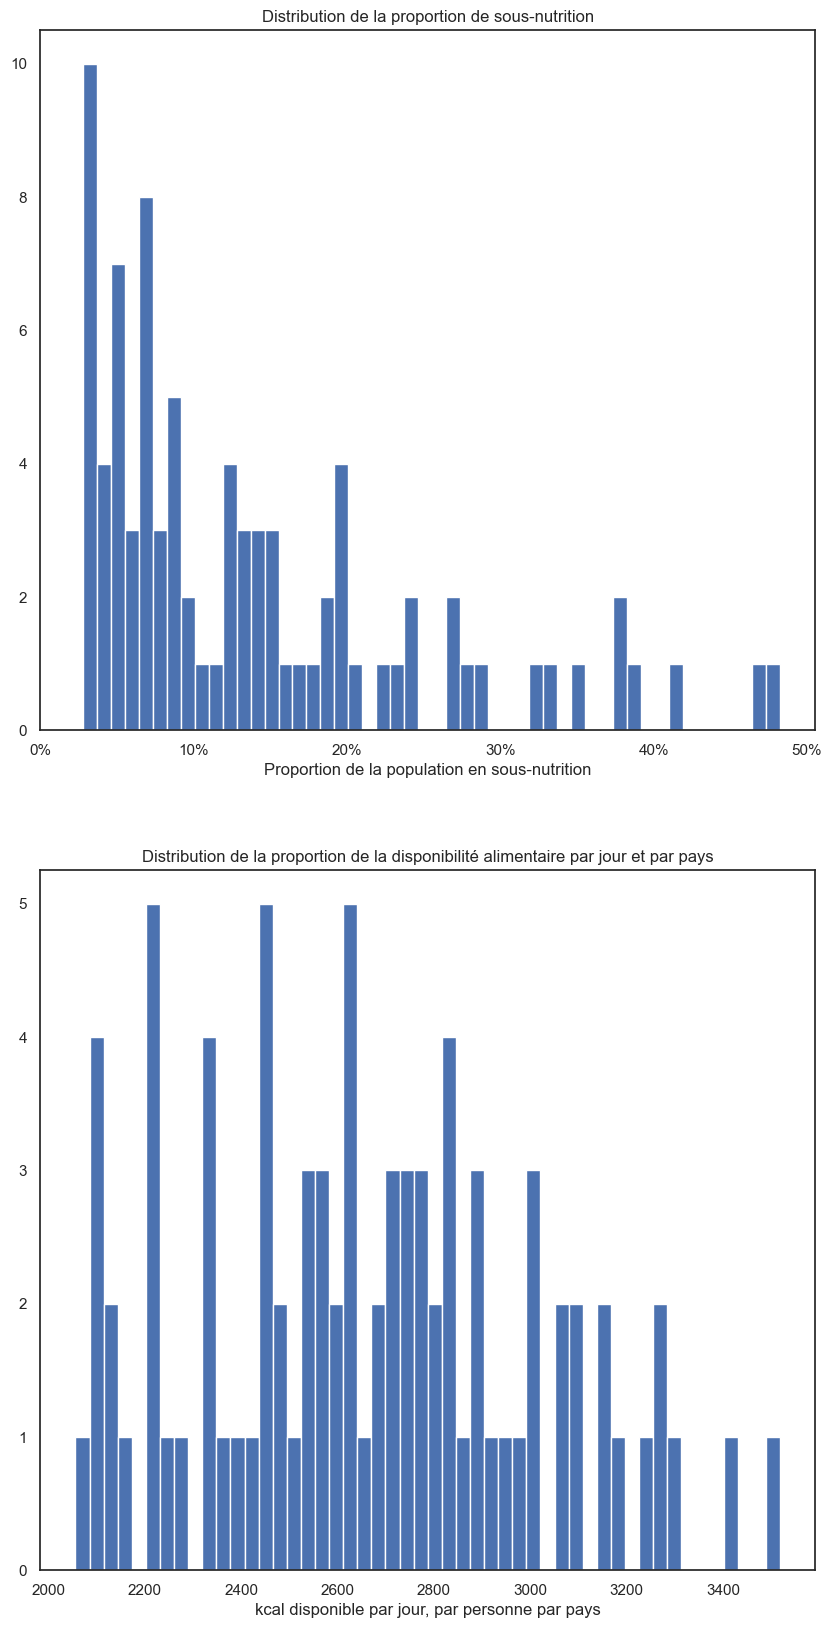

In [115]:
#Correlation entre la dispo en kcal et la sous nutrition pour les pays en sous nutrition (comme le 1er cas meilleur pour le story telling)

sous_nutrition_with_sous_nutrition = sous_nutrition_orig.dropna(subset=['Valeur'])
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition_with_sous_nutrition = sous_nutrition_with_sous_nutrition.copy()
sous_nutrition_with_sous_nutrition['Valeur'] = sous_nutrition_with_sous_nutrition.loc[:, 'Valeur'] * 1000000

sous_nutrition_real_2017 = sous_nutrition_with_sous_nutrition[sous_nutrition_with_sous_nutrition['Année'] == '2016-2018']
population_sous_nutrition_real_2017 = pd.merge(left=population_2017, right=sous_nutrition_real_2017, on='Zone', how='inner')
population_sous_nutrition_real_2017['proportion_sous_nutrition'] = population_sous_nutrition_real_2017['Valeur'] / population_sous_nutrition_real_2017['Population']

#Merge du dataset contenant les 10 pays ayant la sous-nutrition la plus elevé et celui contenant les calories dispnonible par pays
population_sous_nutrition_real_2017_kcal = pd.merge(left=population_sous_nutrition_real_2017, right=dispo_alimentaire_kcal_personne_jour_pays, how="inner", on="Zone")

# Récupération des valeurs des variable de sous-nutrition et de disponibilité calorique
proportion_sous_nutrition_serie = population_sous_nutrition_real_2017_kcal['proportion_sous_nutrition']
dispo_alimentaire_kcal_pers_jour_serie = population_sous_nutrition_real_2017_kcal['Disponibilité alimentaire (Kcal/personne/jour)']

#Graphique contenat la distribution des varaibles taux de sous-nutrition et disponibilité en kcal
fig,axes = plt.subplots(2,1)
fig.set_size_inches(10, 20)

axes[0].hist(proportion_sous_nutrition_serie, bins=50) 

axes[0].set_xlabel('Proportion de la population en sous-nutrition')
axes[0].set_xticks(ticks=[0,0.1,0.2,0.3,0.4,0.5])
axes[0].set_xticklabels(['{:,.0%}'.format(x_values) for x_values in axes[0].get_xticks()])
axes[0].set_title("Distribution de la proportion de sous-nutrition")


axes[1].hist(dispo_alimentaire_kcal_pers_jour_serie, bins=50)

axes[1].set_xlabel('kcal disponible par jour, par personne par pays')
axes[1].set_title("Distribution de la proportion de la disponibilité alimentaire par jour et par pays")

plt.show()

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Les varaibles sous-nutrition et disponibilité alimentaire ne suivent pas une loi normale donc pour vérifier s'il y a une corrélation entre ces 2 varaibles nous allons faire un test de Spearman
</p>
</div>

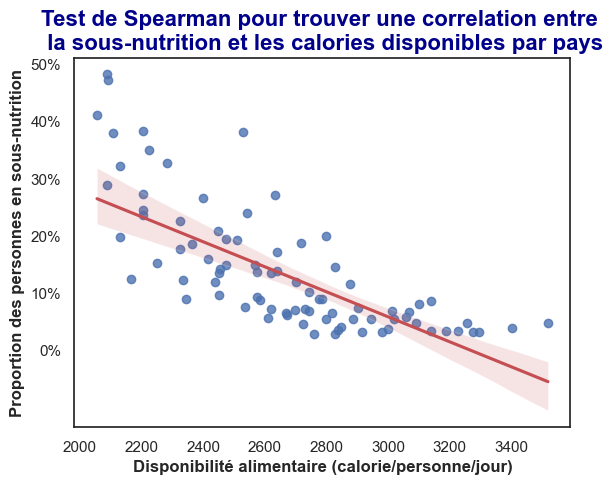

Coefficient de corrélation de Spearman: -0.8308823158138878
Valeur p: 1.4018697045907594e-22


In [116]:
#Test de Spearman
# Visualisation de la tendance
sns.regplot(data=population_sous_nutrition_real_2017_kcal, x="Disponibilité alimentaire (Kcal/personne/jour)", y="proportion_sous_nutrition", robust=True, line_kws=dict(color="r"))


# Calculer le coefficient de corrélation de Spearman et la valeur p
spearman_corr, spearman_p_value = spearmanr(dispo_alimentaire_kcal_pers_jour_serie, proportion_sous_nutrition_serie)
plt.xlabel('Disponibilité alimentaire (calorie/personne/jour)', weight='bold')
plt.ylabel('Proportion des personnes en sous-nutrition', weight='bold')
plt.yticks(ticks = [0,0.1,0.2,0.3,0.4,0.5], labels= ['0%','10%','20%','30%','40%','50%'])
plt.title("Test de Spearman pour trouver une correlation entre \n la sous-nutrition et les calories disponibles par pays", color='darkblue', fontsize=16, weight='bold')

plt.show()
print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Le coefficient de corrélation de Spearman est de -0.83 et la valeur par est inférieur à 0.05 donc la disponibilité alimentaire par pays est inversement correlée au taux de sous nutrition par pays
<br/>
Pour diminuer la sous-nutrition, il faudrait dans le mesure du possible augmenter l'aide alimentaire aux pays qui ont une faible disponibilité alimentaire nea
</p>
</div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Suggestions pour diminuer la sous-nutrition</h2>
</div>

<div>
<p style="margin: auto; padding: 20px; color: RGB(0,150,250);">
Bien que les disponibilité alimentaire mondiale permettent de nourrir toute la population, il existe des disparités de répartition de la disponibilité alimentaire dans les pays.
<br/>
Cette disparité est due à plusieurs facteurs comme la situation géopolitique du pays, la situation géographique du pays, la politique économique du pays.
</p>

<p style="margin: auto; padding-left: 20px; color: RGB(0,150,250);">
Voici quelques suggestions pour atteindre la sécurité alimentaire dans le monde
</p>
<ul style="margin: auto; padding-left: 40px; color: RGB(0,150,250);">
<li>
Augmenter l'aide alimentaire au pays n'ayant pas atteint la disponibilité alimentaire journalière par personne
</li>
<li>
Augmenter l'aide alimentaire au pays se trouvant dans des zones de guerre et dans les pays où il y a des famines
</li>
<li>
Diminuer les exportations des produits alimentaire dans les pays ayant un taux de sous-nutrition élevé
</li>
<li>
Augmenter les importations des produits alimentaire dans les pays ayant un taux de sous-nutrition élevé
</li>
<li>
Céder une partie de la part de produit alimentaires consommées par les animaux à la nourriture humaine dans les pays ayant un taux de sous-nutrition élevé
</li>
</ul>
</div>